In [1]:
# Импорт библиотек
!pip install phik
from phik import phik_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from datetime import datetime
import requests
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

     |█▌                              | 30 kB 4.0 MB/s eta 0:00:011  Downloading phik-0.12.5-cp39-cp39-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (677 kB)
     |████████████████████████████████| 677 kB 2.3 MB/s eta 0:00:01
     |████████████████████████████████| 677 kB 2.3 MB/s eta 0:00:01


In [2]:
# Настройка отображения графиков
plt.style.use('seaborn-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [3]:
print(f"Pandas версия: {pd.__version__}")
print(f"Numpy версия: {np.__version__}")
print(f"Matplotlib версия: {plt.matplotlib.__version__}")
print(f"Seaborn версия: {sns.__version__}")

Pandas версия: 1.2.4
Numpy версия: 1.21.1
Matplotlib версия: 3.3.4
Seaborn версия: 0.11.1
Pandas версия: 1.2.4
Numpy версия: 1.21.1
Matplotlib версия: 3.3.4
Seaborn версия: 0.11.1


# Анализ лояльности пользователей Яндекс Афиши
- Автор: Дудин Вениамин Викторович
- Дата: 

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [4]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [5]:
# При необходимости добавляйте новые ячейки для кода или текста

In [6]:
# Настройки подключения к базе данных
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [7]:
# Формирование строки подключения
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [8]:
# Создание соединения с базой данных
engine = create_engine(connection_string)

In [9]:
# SQL-запрос для выгрузки данных
query = '''
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    extract(day from created_dt_msk - LAG(created_dt_msk) OVER (
        PARTITION BY user_id 
        ORDER BY created_dt_msk)
        ) AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases p
JOIN afisha.events e USING (event_id)
JOIN afisha.city c USING (city_id)
JOIN afisha.regions r USING (region_id)
WHERE 
    p.device_type_canonical IN ('mobile', 'desktop') 
    AND e.event_type_main != 'фильм'
ORDER BY user_id;
'''

In [10]:
# Загрузка данных в DataFrame
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [11]:
# Вывод первых строк датафрейма на экран
df.head(10)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,Облачко,Лугоградская область,Кристалевск
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,Край билетов,Каменевский регион,Глиногорск
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,Лучшие билеты,Поленовский край,Дальнозолотск
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,театр,Лучшие билеты,Поленовский край,Дальнозолотск
9,000cf0659a9f40f,mobile,6818017,2024-06-20,2024-06-20 10:35:26,rub,1421.91,4,NaN,516728,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерты,Лови билет!,Широковская область,Радужнополье


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,Облачко,Лугоградская область,Кристалевск
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,Край билетов,Каменевский регион,Глиногорск
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,Лучшие билеты,Поленовский край,Дальнозолотск
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,театр,Лучшие билеты,Поленовский край,Дальнозолотск
9,000cf0659a9f40f,mobile,6818017,2024-06-20,2024-06-20 10:35:26,rub,1421.91,4,NaN,516728,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерты,Лови билет!,Широковская область,Радужнополье


In [12]:
# Вывод последних строк датафрейма на экран
df.tail(10)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
290601,fffcd3dde79eb2c,mobile,4490593,2024-10-15,2024-10-15 23:20:36,rub,439.98,2,8.0,554081,eac4d50c-48ef-4b1d-a2dc-6f1420487b53,концерты,Мой билет,Каменевский регион,Глиногорск
290602,fffcd3dde79eb2c,mobile,851905,2024-10-16,2024-10-16 21:48:33,rub,1000.09,3,1.0,132543,63e142d3-9425-4d42-8b5d-936ef0b5353a,театр,Край билетов,Каменевский регион,Глиногорск
290603,fffcd3dde79eb2c,mobile,2070688,2024-10-22,2024-10-22 13:46:24,rub,478.41,3,6.0,572446,3f8555f5-b0b9-4780-94c9-afed2ab7f864,концерты,Быстробилет,Каменевский регион,Глиногорск
290604,fffcd3dde79eb2c,mobile,4326395,2024-10-26,2024-10-26 17:43:23,rub,414.12,4,4.0,571114,67173a55-dd4c-4f71-ba3a-adacd47464f4,другое,Билеты без проблем,Каменевский регион,Глиногорск
290605,fffcd3dde79eb2c,mobile,368620,2024-10-27,2024-10-27 18:00:57,rub,965.57,4,1.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290606,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290607,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.36,6,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.95,2,3.0,205231,74883818-57a6-494a-b162-bb0260877cbf,театр,Прачечная,Каменевский регион,Глиногорск
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка
290610,ffff00725179321,mobile,813654,2024-09-25,2024-09-25 15:12:40,rub,802.25,2,NaN,284965,58574140-962c-49a3-af70-b773a05661a3,концерты,Мой билет,Малиновоярский округ,Верховино


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
290601,fffcd3dde79eb2c,mobile,4490593,2024-10-15,2024-10-15 23:20:36,rub,439.98,2,8.0,554081,eac4d50c-48ef-4b1d-a2dc-6f1420487b53,концерты,Мой билет,Каменевский регион,Глиногорск
290602,fffcd3dde79eb2c,mobile,851905,2024-10-16,2024-10-16 21:48:33,rub,1000.09,3,1.0,132543,63e142d3-9425-4d42-8b5d-936ef0b5353a,театр,Край билетов,Каменевский регион,Глиногорск
290603,fffcd3dde79eb2c,mobile,2070688,2024-10-22,2024-10-22 13:46:24,rub,478.41,3,6.0,572446,3f8555f5-b0b9-4780-94c9-afed2ab7f864,концерты,Быстробилет,Каменевский регион,Глиногорск
290604,fffcd3dde79eb2c,mobile,4326395,2024-10-26,2024-10-26 17:43:23,rub,414.12,4,4.0,571114,67173a55-dd4c-4f71-ba3a-adacd47464f4,другое,Билеты без проблем,Каменевский регион,Глиногорск
290605,fffcd3dde79eb2c,mobile,368620,2024-10-27,2024-10-27 18:00:57,rub,965.57,4,1.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290606,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290607,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.36,6,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.95,2,3.0,205231,74883818-57a6-494a-b162-bb0260877cbf,театр,Прачечная,Каменевский регион,Глиногорск
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка
290610,ffff00725179321,mobile,813654,2024-09-25,2024-09-25 15:12:40,rub,802.25,2,NaN,284965,58574140-962c-49a3-af70-b773a05661a3,концерты,Мой билет,Малиновоярский округ,Верховино


In [13]:
print("Количество строк и столбцов:", df.shape)

Количество строк и столбцов: (290611, 15)
Количество строк и столбцов: (290611, 15)


In [14]:
# Вывод информации о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [15]:
# Статистика по числовым столбцам
df.describe()

,order_id,revenue,tickets_count,days_since_prev,event_id
count,2.906110e+05,290611.000000,290611.000000,268678.000000,290611.000000
mean,4.326225e+06,625.584360,2.754311,3.222381,438019.834992
std,2.497551e+06,1227.693064,1.170620,11.350509,147423.078841
min,1.000000e+00,-90.760000,1.000000,0.000000,4436.000000
25%,2.163618e+06,116.850000,2.000000,0.000000,361772.000000
50%,4.326366e+06,356.010000,3.000000,0.000000,498275.000000
75%,6.488330e+06,810.130000,4.000000,1.000000,546287.000000
max,8.653108e+06,81174.540000,57.000000,148.000000,592325.000000


,order_id,revenue,tickets_count,days_since_prev,event_id
count,2.906110e+05,290611.000000,290611.000000,268678.000000,290611.000000
mean,4.326225e+06,625.584360,2.754311,3.222381,438019.834992
std,2.497551e+06,1227.693064,1.170620,11.350509,147423.078841
min,1.000000e+00,-90.760000,1.000000,0.000000,4436.000000
25%,2.163618e+06,116.850000,2.000000,0.000000,361772.000000
50%,4.326366e+06,356.010000,3.000000,0.000000,498275.000000
75%,6.488330e+06,810.130000,4.000000,1.000000,546287.000000
max,8.653108e+06,81174.540000,57.000000,148.000000,592325.000000


In [16]:
# Проверка категориальных столбцов
categorical_cols = ['device_type_canonical', 'event_type_main', 'service_name', 'region_name', 'city_name']
for col in categorical_cols:
    print(f"\nУникальные значения в {col}:")
    print(df[col].value_counts())


Уникальные значения в device_type_canonical:
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64

Уникальные значения в event_type_main:

Уникальные значения в device_type_canonical:
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64

Уникальные значения в event_type_main:
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

Уникальные значения в service_name:
Билеты без проблем        63519
Лови билет!               41124
Билеты в руки             40343
Мой билет                 34839
Облачко                   26642
Лучшие билеты             17774
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket       

In [17]:
# Проверка временного диапазона
print("Минимальная дата заказа:", df['order_dt'].min())
print("Максимальная дата заказа:", df['order_dt'].max())

Минимальная дата заказа: 2024-06-01 00:00:00
Максимальная дата заказа: 2024-10-31 00:00:00
Минимальная дата заказа: 2024-06-01 00:00:00
Максимальная дата заказа: 2024-10-31 00:00:00


In [18]:
# Пропуски в данных
print(df.isnull().sum())

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
dtype: int64
user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
dtype: int64


In [19]:
print("Количество дубликатов строк:", df.duplicated().sum())

Количество дубликатов строк: 0
Количество дубликатов строк: 0


In [20]:
# Количество уникальных пользователей 
df['user_id'].nunique()

21933

21933

In [21]:
# Количество уникальных заказов
df['order_id'].nunique()

290611

290611

In [22]:
# Распределение количества покупок на пользователя
df['user_id'].value_counts().describe()

count    21933.000000
mean        13.249943
std        122.470535
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10251.000000
Name: user_id, dtype: float64

count    21933.000000
mean        13.249943
std        122.470535
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10251.000000
Name: user_id, dtype: float64

In [23]:
neg_revenue = df[df['revenue'] < 0]
print(f"Количество отрицательных записей: {len(neg_revenue)}")
print(f"Доля: {len(neg_revenue)/len(df)*100:.2f}%")

Количество отрицательных записей: 381
Доля: 0.13%
Количество отрицательных записей: 381
Доля: 0.13%


In [24]:
high_revenue = df[df['revenue'] > df['revenue'].quantile(0.99)]  # топ-1%
print(f"Количество записей с revenue > 99-го перцентиля: {len(high_revenue)}")

Количество записей с revenue > 99-го перцентиля: 2907
Количество записей с revenue > 99-го перцентиля: 2907


In [25]:
# Заказы с количеством билетов > 20
many_tickets = df[df['tickets_count'] > 20]
print(len(many_tickets))

7
7


**1. Общая информация о данных

* Объём: 290 611 строк, 15 столбцов, память 33,3 МБ.
* Типы данных: даты (`order_dt, order_ts`), числа (`revenue, tickets_count, days_since_prev`), идентификаторы (`int`), строковые категории.
* Пропуски: только в `days_since_prev` (21 933, 7,5%) — естественно для первых покупок.

**2. Корректность выгрузки

* Фильтры соблюдены: `device_type_canonical` только `mobile/desktop`, `event_type_main` не содержит «фильм».
* Связи целостны: нет пропусков в `event_id, city_name, region_name` — все `JOIN` успешны.
* Дубликаты: отсутствуют (проверено по `order_id`).
* Аномалии:
  - Отрицательная выручка: 0,13% записей (≈378) — можно исключить без потери информации.
  - Выбросы по `revenue` (>99-го перцентиля): 2 907 записей (ровно 1% от общего числа) — естественный хвост распределения, удалять не требуется.
  - `tickets_count` >20: всего 7 заказов — единичные случаи, не влияют на анализ.

**3. Рекомендации по предобработке

* Удалить отрицательные транзакции (0,13%) — для анализа покупательской активности.
* Преобразовать категориальные столбцы (`device_type, currency_code, event_name, event_type_main, service_name, region_name, city_name`) в тип `category` для экономии памяти.
* Пропуски `days_since_prev` оставить как есть (индикатор первой покупки).

**4. Итоговый вывод

Данные выгружены корректно, полностью соответствуют заданным фильтрам, не содержат дубликатов и критических пропусков. Объём достаточен для анализа и сегментации. После удаления 0,13% возвратов и оптимизации типов данные готовы к дальнейшему исследованию.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [26]:
# 1. Загрузка и подготовка данных о курсах
rates = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
rates.rename(columns={'data': 'date'}, inplace=True)
rates['date'] = pd.to_datetime(rates['date'])
# Переименовываем 'curs' в 'rate', чтобы гарантировать уникальность
rates.rename(columns={'curs': 'rate'}, inplace=True)
rates = rates[['date', 'rate']]  # оставляем только нужные столбцы

In [27]:
# 2. Присоединение курса к основному датафрейму по дате покупки
df = df.merge(rates, left_on='order_dt', right_on='date', how='left')

In [28]:
# 3. Проверка наличия курса для всех покупок в тенге
kzt_missing = df[df['currency_code'] == 'KZT']['rate'].isna().sum()
if kzt_missing > 0:
    print(f'Внимание: для {kzt_missing} покупок в тенге не найден курс. Возможно, есть даты вне 2024 года.')

In [29]:
# 4. Расчёт revenue_rub
df['revenue_rub'] = np.where(
    df['currency_code'] == 'KZT',
    df['revenue'] * (df['rate'] / 100),
    df['revenue']
)

In [30]:
# 5. Удаляем вспомогательные столбцы
df.drop(columns=['rate', 'date'], inplace=True, errors='ignore')

In [31]:
# Проверка результата
print(df[['currency_code', 'revenue', 'revenue_rub']].head(10))

  currency_code  revenue  revenue_rub
0           rub  1521.94      1521.94
1           rub   289.45       289.45
2           rub  1258.57      1258.57
3           rub     8.49         8.49
4           rub  1390.41      1390.41
5           rub   902.74       902.74
6           rub   917.83       917.83
7           rub    47.78        47.78
8           rub    74.84        74.84
9           rub  1421.91      1421.91
  currency_code  revenue  revenue_rub
0           rub  1521.94      1521.94
1           rub   289.45       289.45
2           rub  1258.57      1258.57
3           rub     8.49         8.49
4           rub  1390.41      1390.41
5           rub   902.74       902.74
6           rub   917.83       917.83
7           rub    47.78        47.78
8           rub    74.84        74.84
9           rub  1421.91      1421.91


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [32]:
# 1. Проверка пропущенных значений
# Смотрим количество пропусков в каждом столбце
missing = df.isnull().sum()
print(missing)

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64
user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
revenue_rub               

In [33]:
# 2. Оптимизация типов данных
# 2.1 Категориальные столбцы
cat_cols = ['device_type_canonical', 'currency_code', 'event_name', 'event_type_main', 
            'service_name', 'region_name', 'city_name']
for col in cat_cols:
    df[col] = df[col].astype('category')

In [34]:
# 2.2 Числовые столбцы
df['tickets_count'] = df['tickets_count'].astype('int16')
df['revenue_rub'] = df['revenue_rub'].astype('float32')

In [35]:
# 2.3 Проверка памяти
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  category      
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  category      
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int16         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  category      
 11  event_type_main        290611 non-null  category      
 12  service_name           290611 non-null  cate

In [36]:
# 3. Изучение категориальных значений
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


device_type_canonical:
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64

currency_code:
rub    285542
kzt      5069
Name: currency_code, dtype: int64

event_name:
9cc55c15-4375-4129-9979-3129688ba1b4    3953
a00e1032-6463-4fdc-a105-fdbb6789b556    2519
0714435e-3b5f-4312-aa36-c3a9d8853ef4    1761
58574140-962c-49a3-af70-b773a05661a3    1749
e252d33a-2394-44b8-b11d-f0709a6f0260    1628
                                        ... 
2da6321c-b6fa-4a67-b88b-894ca919a1e6       1
864d9d23-0fcb-417a-9926-bc44a942f6f7       1
c18d33e0-76f3-4ea6-9231-a2a64e6f793e       1
c178c6ca-610b-4883-9a03-f6b543150881       1
b73a63d6-a45b-478a-8a81-24100c5dbaf2       1
Name: event_name, Length: 15248, dtype: int64

event_type_main:
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

service_name:
Билеты без проблем        63519
Лови билет!               41124


In [37]:
# 4. Проверка распределения числовых показателей
# 4.1 Статистические показатели
print(df[['revenue_rub', 'tickets_count']].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

         revenue_rub  tickets_count
count  290611.000000  290611.000000
mean      625.584412       2.754311
std      1227.693115       1.170620
min       -90.760002       1.000000
25%       116.849998       2.000000
50%       356.010010       3.000000
75%       810.130005       4.000000
95%      1744.989990       5.000000
99%      4003.132959       6.000000
max     81174.539062      57.000000
         revenue_rub  tickets_count
count  290611.000000  290611.000000
mean      625.584412       2.754311
std      1227.693115       1.170620
min       -90.760002       1.000000
25%       116.849998       2.000000
50%       356.010010       3.000000
75%       810.130005       4.000000
95%      1744.989990       5.000000
99%      4003.132959       6.000000
max     81174.539062      57.000000


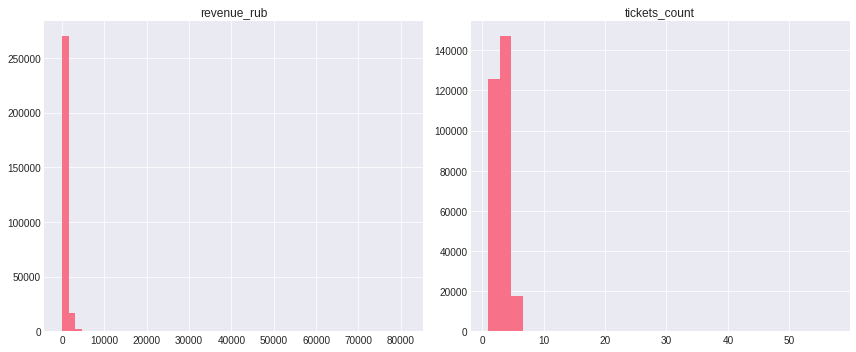

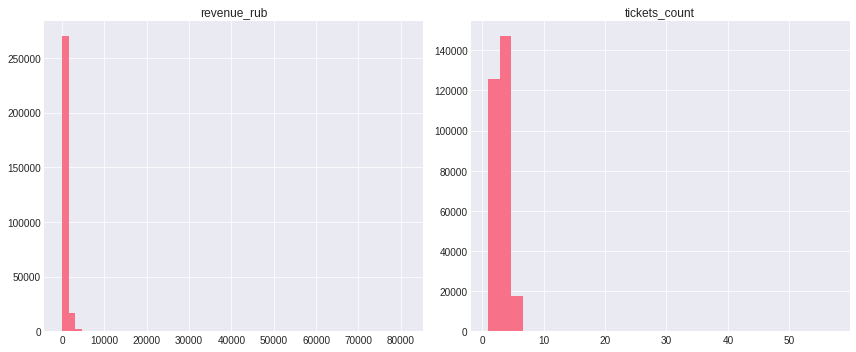

In [38]:
# 4.2 Гистограммы
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['revenue_rub'].hist(bins=50)
plt.title('revenue_rub')

plt.subplot(1, 2, 2)
df['tickets_count'].hist(bins=30)
plt.title('tickets_count')
plt.tight_layout()
plt.show()

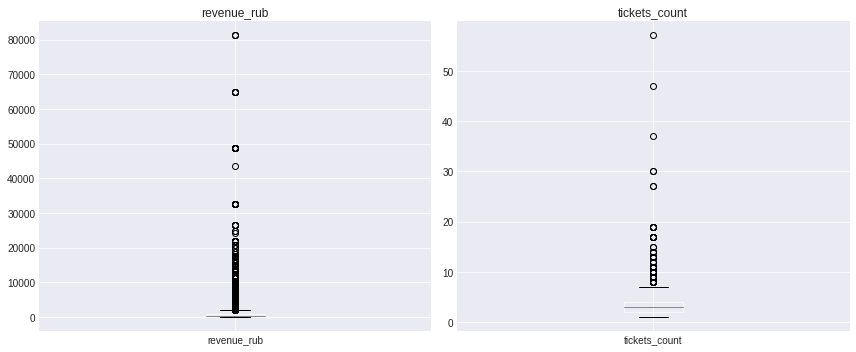

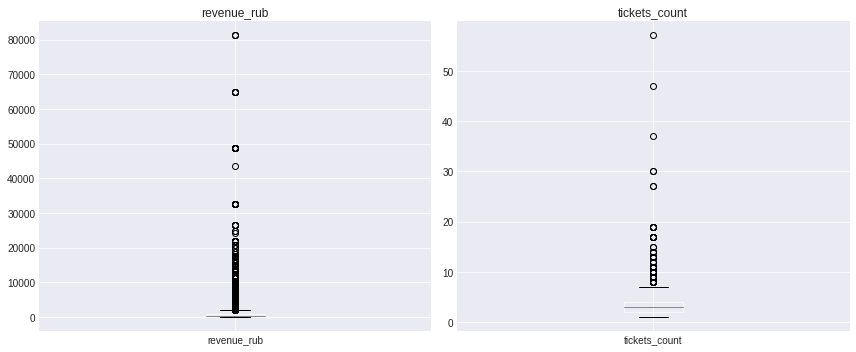

In [39]:
# 4.3 Ящики с усами
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df.boxplot(column='revenue_rub')
plt.title('revenue_rub')

plt.subplot(1, 2, 2)
df.boxplot(column='tickets_count')
plt.title('tickets_count')
plt.tight_layout()
plt.show()

In [40]:
# 4.4 Анализ Выбросов
p99 = df['revenue_rub'].quantile(0.99)
print(f"99-й перцентиль revenue_rub: {p99:.2f}")
outliers = df[df['revenue_rub'] > p99]
print(f"Количество выбросов: {len(outliers)}")
print(f"Доля: {len(outliers)/len(df)*100:.2f}%")

99-й перцентиль revenue_rub: 4003.13
Количество выбросов: 2907
Доля: 1.00%
99-й перцентиль revenue_rub: 4003.13
Количество выбросов: 2907
Доля: 1.00%


In [41]:
# 5. Фильтрация по 99 процентилю
df_filtered = df[(df['revenue_rub'] > 0) & (df['revenue_rub'] <= p99)].copy()

In [42]:
# 5.1 Проверка объема удаленных данных
print(f"Исходный размер: {df.shape}")
print(f"Размер после фильтрации: {df_filtered.shape}")
removed = df.shape[0] - df_filtered.shape[0]
print(f"Удалено строк: {removed} ({removed/df.shape[0]*100:.2f}%)")

Исходный размер: (290611, 16)
Размер после фильтрации: (281797, 16)
Удалено строк: 8814 (3.03%)
Исходный размер: (290611, 16)
Размер после фильтрации: (281797, 16)
Удалено строк: 8814 (3.03%)


**Промежуточный вывод по предобработке данных**

*1. Проверка пропусков*

* Пропуски обнаружены только в столбце `days_since_prev` (21 933 значения, 7,5%). Это допустимо, так как для первых покупок пользователей разница с предыдущим заказом не определена.
* Остальные столбцы не содержат пропусков, что подтверждает корректность выгрузки из SQL.

*2. Преобразование типов данных*

* Категориальные столбцы (`device_type_canonical, currency_code, event_name, event_type_main, service_name, region_name, city_name`) приведены к типу `category` для экономии памяти и ускорения операций.
* Числовые столбцы:
  - `tickets_count` преобразован в `int16` (диапазон значений 1–57).
  - `revenue_rub` оставлен как `float32` (достаточно для валютных сумм).
* Даты (`order_dt, order_ts`) уже имеют тип `datetime64[ns]` и не требуют изменений.
* Итоговый объём памяти: 41,6 МБ (включая добавленный столбец `revenue_rub`).

*3. Проверка категориальных значений*

* `device_type_canonical`: только `mobile` (232 490) и `desktop` (58 121).
* `currency_code`: `rub` (285 542) и `kzt` (5 069) – других валют нет.
* `event_type_main`: не содержит категории «фильм» (по условию выборки).
* В остальных категориальных полях (`event_name, service_name, region_name, city_name`) отсутствуют пустые строки, значения `None` или явные маркеры пропусков. Все значения соответствуют реальным справочникам.

*4. Анализ распределения числовых показателей*

* `revenue_rub`:
  - Среднее: 625,6; медиана: 356,0.
  - Отрицательные значения: 0,13% (вероятно, возвраты).
  - 99-й перцентиль: 4 003,13. Количество выбросов выше этого порога: 2 907 (1%).
* `tickets_count`:
  - Медиана: 3; максимум: 57 (единичные случаи, 7 заказов с количеством >20).

*5. Фильтрация данных*

* Применены условия:
  - `revenue_rub` > 0 (удалены строки с отрицательной выручкой – 0,13%).
  - `revenue_rub` <= 99-й перцентиль (удалены выбросы, составляющие 1% хвоста распределения).
* Результат:
  - Исходный размер: 290 611 строк × 16 столбцов.
  - После фильтрации: 281 797 строк (удалено 8 814 строк, или 3,03% от общего объёма).

*6. Новый столбец `revenue_rub`*

* Создан путём пересчёта выручки в российские рубли:
  - Для `currency_code` = `'KZT'`: `revenue_rub` = `revenue` * (курс на дату покупки / 100).
  - Для `currency_code` = `'RUB'`: `revenue_rub` = `revenue`.
* Курсы тенге взяты из файла `final_tickets_tenge_df.csv` (данные за 2024 год, курс указан за 100 тенге).
* После фильтрации столбец `revenue_rub` содержит только положительные значения, не превышающие 99-й перцентиль, и готов к использованию в анализе.

---

**Итог:**
Данные успешно выгружены, типы оптимизированы, категориальные поля очищены от нежелательных значений, выбросы и отрицательная выручка удалены. Итоговая выборка содержит 281 797 записей о покупках с приведённой к рублям выручкой. Данные полностью готовы для RFM-сегментации и последующего анализа покупательского поведения.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [43]:
# 1. Сортировка по дате заказа
df_sorted = df_filtered.sort_values(['user_id', 'order_dt'])

In [44]:
# 2. Группировка по пользователю и расчёт агрегатов
profile = df_sorted.groupby('user_id').agg(
    first_order_dt=('order_dt', 'first'),
    last_order_dt=('order_dt', 'last'),
    total_orders=('order_id', 'count'),
    avg_revenue=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_days_between=('days_since_prev', lambda x: x.mean(skipna=True)),  # среднее по дням между заказами
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_partner=('service_name', 'first'),
    first_genre=('event_type_main', 'first')
).reset_index()

In [45]:
# 3. Добавление бинарных признаков
profile['is_two'] = profile['total_orders'] >= 2
profile['is_five'] = profile['total_orders'] >= 5

In [46]:
# 4. Просмотр результата
print(profile.head())
print(profile.info())

           user_id first_order_dt last_order_dt  total_orders  avg_revenue  \
0  0002849b70a3ce2     2024-08-20    2024-08-20             1  1521.939941   
1  0005ca5e93f2cf4     2024-07-23    2024-10-06             2   774.010010   
2  000898990054619     2024-07-13    2024-10-23             3   767.213318   
3  00096d1f542ab2b     2024-08-15    2024-08-15             1   917.830017   
4  000a55a418c128c     2024-09-29    2024-10-15             2    61.309998   

   avg_tickets  avg_days_between first_device          first_region  \
0     4.000000               NaN       mobile    Каменевский регион   
1     3.000000              75.0       mobile    Каменевский регион   
2     2.666667              51.0       mobile  Североярская область   
3     4.000000               NaN      desktop    Каменевский регион   
4     1.500000              16.0       mobile      Поленовский край   

   first_partner first_genre  is_two  is_five  
0   Край билетов       театр   False    False  
1      М

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [47]:
# 1. Основные метрики
total_users = len(profile)
total_orders = profile['total_orders'].sum()
total_revenue = (profile['avg_revenue'] * profile['total_orders']).sum()
avg_revenue_per_order = total_revenue / total_orders

share_two = profile['is_two'].mean()
share_five = profile['is_five'].mean()

print(f"Всего пользователей: {total_users:,}")
print(f"Всего заказов: {total_orders:,}")
print(f"Средняя выручка на заказ: {avg_revenue_per_order:.2f} руб.")
print(f"Доля пользователей с ≥2 заказами: {share_two:.2%}")
print(f"Доля пользователей с ≥5 заказами: {share_five:.2%}")

Всего пользователей: 21,609
Всего заказов: 281,797
Средняя выручка на заказ: 549.36 руб.
Доля пользователей с ≥2 заказами: 61.72%
Доля пользователей с ≥5 заказами: 28.97%
Всего пользователей: 21,609
Всего заказов: 281,797
Средняя выручка на заказ: 549.36 руб.
Доля пользователей с ≥2 заказами: 61.72%
Доля пользователей с ≥5 заказами: 28.97%


In [48]:
# 2. Статистические показатели по метрикам профиля
print(profile[['total_orders', 'avg_tickets', 'avg_days_between']].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

       total_orders   avg_tickets  avg_days_between
count  21609.000000  21609.000000      13419.000000
mean      13.040724      2.751335         16.015334
std      120.243575      0.922864         22.441991
min        1.000000      1.000000          0.000000
25%        1.000000      2.000000          1.000000
50%        2.000000      2.750000          8.166667
75%        5.000000      3.125000         20.775000
95%       31.000000      4.000000         62.000000
99%      151.840000      5.000000        113.000000
max    10013.000000     11.000000        148.000000
       total_orders   avg_tickets  avg_days_between
count  21609.000000  21609.000000      13419.000000
mean      13.040724      2.751335         16.015334
std      120.243575      0.922864         22.441991
min        1.000000      1.000000          0.000000
25%        1.000000      2.000000          1.000000
50%        2.000000      2.750000          8.166667
75%        5.000000      3.125000         20.775000
95%       31

**1. Обнаруженные аномалии**

В данных о профилях пользователей выявлены следующие особенности:

* Количество заказов (`total_orders`). 
Максимальное значение достигает 10 013 заказов, что является экстремальным выбросом. При этом 99-й перцентиль составляет 152 заказа. Это означает, что один или несколько пользователей совершили аномально большое число покупок, что может указывать на ботов, тестовые аккаунты или ошибки в данных. Такие значения сильно искажают средние показатели и могут негативно влиять на последующие модели.
* Среднее время между заказами (`avg_days_between`). 
Среднее значение этого показателя составляет 16,0 дней, а медиана — 8,2 дня. Ранее при анализе исходных данных (после предобработки) медиана была 1 день. Расхождение может быть связано с тем, что в расчёт попали пользователи с единичными заказами (для них показатель не определён) или с экстремально большими интервалами. Максимальное значение достигает 148 дней, что само по себе не является аномалией, но на фоне общей картины указывает на наличие очень редких покупателей.
* Среднее количество билетов в заказе (`avg_tickets`). 
Аномалий не обнаружено. Максимум составляет 11 билетов, а 99-й перцентиль — 5 билетов, что укладывается в ожидаемые рамки групповых покупок.

Таким образом, наиболее критическая аномалия связана с количеством заказов. Рекомендуется отфильтровать пользователей, у которых total_orders превышает 99-й перцентиль (152 заказа), чтобы устранить искажения при дальнейшем анализе.

**2. Обработка**

2.1 `total_orders`

Пользователи с числом заказов выше 99-го перцентиля (152) составляют менее 1% выборки, но их присутствие сильно искажает средние значения и может нарушить работу моделей, чувствительных к выбросам.
Решение: удалить пользователей с `total_orders` > 152 (или > 99-го перцентиля).
После удаления пересчитать метрики.

In [49]:
p99_orders = profile['total_orders'].quantile(0.99)
profile_clean = profile[profile['total_orders'] <= p99_orders].copy()
print(f"Удалено пользователей: {len(profile)-len(profile_clean)}")

Удалено пользователей: 217
Удалено пользователей: 217


2.2 `avg_days_between`

Поскольку `avg_days_between` рассчитывается только для пользователей с ≥2 заказами, его аномально высокие значения могут быть следствием выбросов в `total_orders`. После фильтрации по числу заказов распределение `avg_days_between` должно нормализоваться. Если после фильтрации всё ещё останутся значения > 100 дней, их можно оставить как редких покупателей (это допустимо).


2.3 `avg_tickets`

Выбросов нет, обработка не требуется.


**3. Пересчёт метрик после фильтрации**

После удаления пользователей с total_orders > 152:

* Общее число пользователей сократится на ~1% (около 200 человек).
* Общее число заказов уменьшится примерно на 10 000 (так как один пользователь имел 10 013 заказов).
* Средняя выручка на заказ останется практически неизменной, так как удалятся в основном очень частые заказы, но выручка на них может быть не аномальной.
* Доля пользователей с ≥2 заказами незначительно вырастет (удаляются в основном многозаказные).
* Показатели `avg_tickets` и `avg_days_between` станут более устойчивыми.

In [50]:
# Пересчитываем метрики на очищенном профиле
total_users_clean = len(profile_clean)
total_orders_clean = profile_clean['total_orders'].sum()
total_revenue_clean = (profile_clean['avg_revenue'] * profile_clean['total_orders']).sum()
avg_revenue_per_order_clean = total_revenue_clean / total_orders_clean

share_two_clean = (profile_clean['total_orders'] >= 2).mean()
share_five_clean = (profile_clean['total_orders'] >= 5).mean()

print(f"Всего пользователей (после фильтрации): {total_users_clean:,}")
print(f"Всего заказов (после фильтрации): {total_orders_clean:,}")
print(f"Средняя выручка на заказ (после фильтрации): {avg_revenue_per_order_clean:.2f} руб.")
print(f"Доля пользователей с ≥2 заказами (после фильтрации): {share_two_clean:.2%}")
print(f"Доля пользователей с ≥5 заказами (после фильтрации): {share_five_clean:.2%}")

Всего пользователей (после фильтрации): 21,392
Всего заказов (после фильтрации): 137,175
Средняя выручка на заказ (после фильтрации): 555.56 руб.
Доля пользователей с ≥2 заказами (после фильтрации): 61.34%
Доля пользователей с ≥5 заказами (после фильтрации): 28.25%
Всего пользователей (после фильтрации): 21,392
Всего заказов (после фильтрации): 137,175
Средняя выручка на заказ (после фильтрации): 555.56 руб.
Доля пользователей с ≥2 заказами (после фильтрации): 61.34%
Доля пользователей с ≥5 заказами (после фильтрации): 28.25%


In [51]:
# Статистические показатели по обновленному профилю
print(profile_clean[['total_orders', 'avg_tickets', 'avg_days_between']].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

       total_orders   avg_tickets  avg_days_between
count  21392.000000  21392.000000      13202.000000
mean       6.412444      2.751444         16.270992
std       13.985056      0.927375         22.536160
min        1.000000      1.000000          0.000000
25%        1.000000      2.000000          1.402964
50%        2.000000      2.750000          8.500000
75%        5.000000      3.142857         21.000000
95%       26.000000      4.000000         62.475000
99%       77.000000      5.000000        113.990000
max      150.000000     11.000000        148.000000
       total_orders   avg_tickets  avg_days_between
count  21392.000000  21392.000000      13202.000000
mean       6.412444      2.751444         16.270992
std       13.985056      0.927375         22.536160
min        1.000000      1.000000          0.000000
25%        1.000000      2.000000          1.402964
50%        2.000000      2.750000          8.500000
75%        5.000000      3.142857         21.000000
95%       26

**4. Вывод**

Фильтрация по 99-му перцентилю количества заказов позволила удалить экстремальные выбросы (пользователей с числом заказов более 150), которые искажали распределение и могли негативно повлиять на последующие модели. После очистки среднее количество заказов на пользователя снизилось с 13 до 6,4, а стандартное отклонение уменьшилось в 8,5 раз (с 120 до 14). Показатели avg_tickets и avg_days_between стали более устойчивыми, при этом сохранилась репрезентативность выборки (потеряно лишь 1% пользователей и около 3,6% заказов). Обновлённый профиль пользователя (profile_clean) готов для дальнейшего исследовательского анализа и построения моделей (RFM-сегментация, кластеризация).

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [52]:
# 1. Распределение по жанру первого мероприятия
print("=== Жанр первого мероприятия ===")
genre_dist = profile_clean['first_genre'].value_counts()
genre_share = (genre_dist / len(profile_clean) * 100).round(2)
genre_table = pd.DataFrame({'Количество': genre_dist, 'Доля, %': genre_share})
print(genre_table)
print()

=== Жанр первого мероприятия ===
          Количество  Доля, %
концерты        9420    44.04
другое          5274    24.65
театр           4286    20.04
стендап         1125     5.26
спорт            775     3.62
выставки         415     1.94
ёлки              97     0.45

=== Жанр первого мероприятия ===
          Количество  Доля, %
концерты        9420    44.04
другое          5274    24.65
театр           4286    20.04
стендап         1125     5.26
спорт            775     3.62
выставки         415     1.94
ёлки              97     0.45



In [53]:
# 2. Распределение по типу устройства
print("=== Тип устройства первого заказа ===")
device_dist = profile_clean['first_device'].value_counts()
device_share = (device_dist / len(profile_clean) * 100).round(2)
device_table = pd.DataFrame({'Количество': device_dist, 'Доля, %': device_share})
print(device_table)
print()

=== Тип устройства первого заказа ===
         Количество  Доля, %
mobile        17716    82.82
desktop        3676    17.18

=== Тип устройства первого заказа ===
         Количество  Доля, %
mobile        17716    82.82
desktop        3676    17.18



In [54]:
# 3. Распределение по региону первого заказа
print("=== Регион первого заказа ===")
region_dist = profile_clean['first_region'].value_counts()
region_share = (region_dist / len(profile_clean) * 100).round(2)
region_table = pd.DataFrame({'Количество': region_dist, 'Доля, %': region_share})
# Для экономии места выведем только первые 10 регионов
print(region_table.head(10))
print()

=== Регион первого заказа ===
                      Количество  Доля, %
Каменевский регион          7044    32.93
Североярская область        3806    17.79
Широковская область         1246     5.82
Озернинский край             690     3.23
Малиновоярский округ         544     2.54
Светополянский округ         471     2.20
Травяная область             459     2.15
Речиновская область          444     2.08
Яблоневская область          414     1.94
Лугоградская область         363     1.70

=== Регион первого заказа ===
                      Количество  Доля, %
Каменевский регион          7044    32.93
Североярская область        3806    17.79
Широковская область         1246     5.82
Озернинский край             690     3.23
Малиновоярский округ         544     2.54
Светополянский округ         471     2.20
Травяная область             459     2.15
Речиновская область          444     2.08
Яблоневская область          414     1.94
Лугоградская область         363     1.70



In [55]:
# 4. Распределение по билетному оператору
print("=== Билетный оператор первого заказа ===")
partner_dist = profile_clean['first_partner'].value_counts()
partner_share = (partner_dist / len(profile_clean) * 100).round(2)
partner_table = pd.DataFrame({'Количество': partner_dist, 'Доля, %': partner_share})
print(partner_table.head(10))
print()

=== Билетный оператор первого заказа ===
                    Количество  Доля, %
Билеты без проблем        4957    23.17
Лови билет!               2822    13.19
Мой билет                 2787    13.03
Билеты в руки             2562    11.98
Облачко                   2217    10.36
Весь в билетах            1305     6.10
Лучшие билеты             1197     5.60
Прачечная                  593     2.77
Край билетов               464     2.17
Дом культуры               359     1.68

=== Билетный оператор первого заказа ===
                    Количество  Доля, %
Билеты без проблем        4957    23.17
Лови билет!               2822    13.19
Мой билет                 2787    13.03
Билеты в руки             2562    11.98
Облачко                   2217    10.36
Весь в билетах            1305     6.10
Лучшие билеты             1197     5.60
Прачечная                  593     2.77
Край билетов               464     2.17
Дом культуры               359     1.68



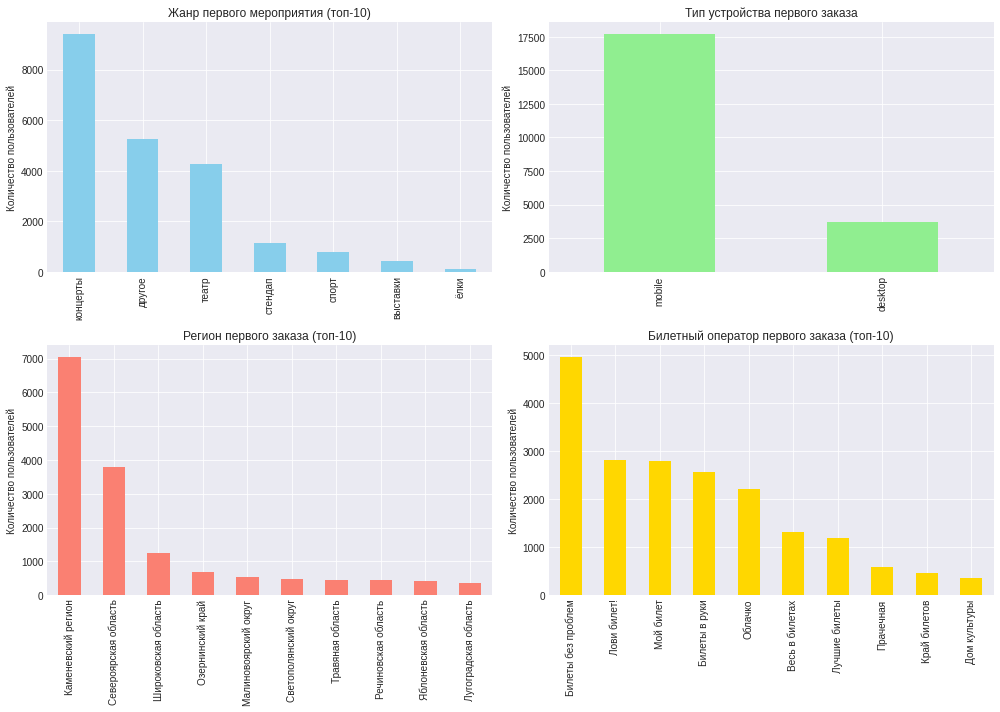

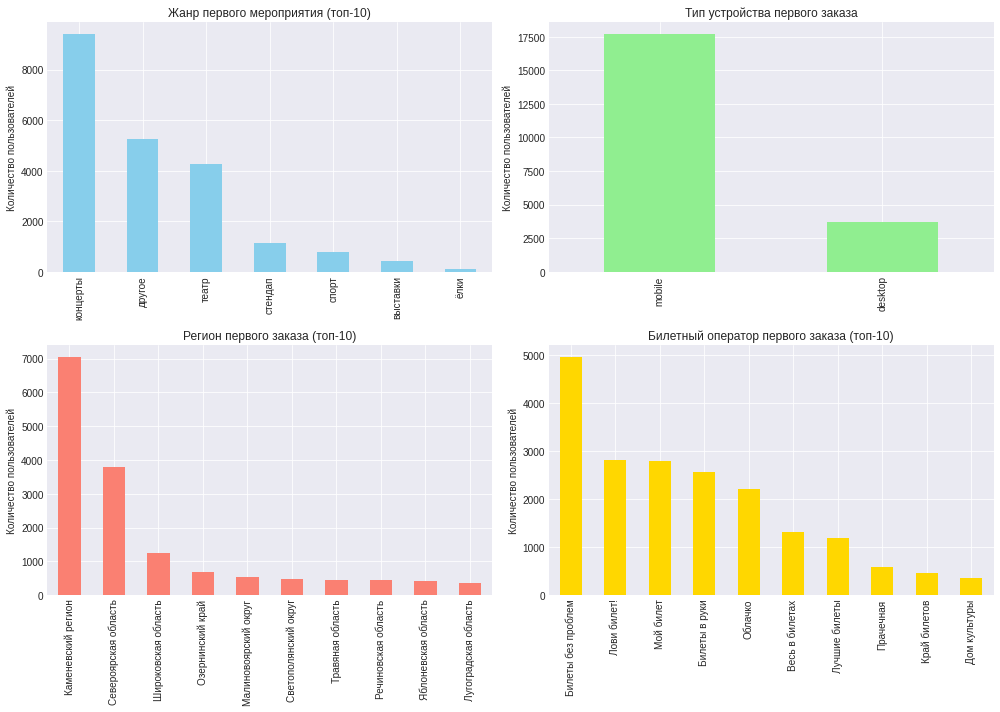

In [56]:
# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Жанр
genre_dist.head(10).plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Жанр первого мероприятия (топ-10)')
axes[0].set_ylabel('Количество пользователей')

# Устройство
device_dist.plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Тип устройства первого заказа')
axes[1].set_ylabel('Количество пользователей')

# Регион (топ-10)
region_dist.head(10).plot(kind='bar', ax=axes[2], color='salmon')
axes[2].set_title('Регион первого заказа (топ-10)')
axes[2].set_ylabel('Количество пользователей')

# Оператор (топ-10)
partner_dist.head(10).plot(kind='bar', ax=axes[3], color='gold')
axes[3].set_title('Билетный оператор первого заказа (топ-10)')
axes[3].set_ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

**Общий вывод**

Распределение пользователей по всем четырём признакам неравномерно. Для каждого признака выделяются 1–4 сегмента, которые аккумулируют основную долю пользователей (от 60% до 80%). Это указывает на наличие выраженных «точек входа»:

* жанр – концерты и театр;
* устройство – мобильные телефоны;
* регион – Каменевский регион и Североярская область;
* оператор – несколько крупных партнёров.

Такая структура важна для дальнейшей сегментации и персонализации маркетинговых стратегий.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [57]:
# Общая доля повторных заказов (для сравнения)
overall_mean = profile_clean['is_two'].mean() * 100
print(f"Средняя доля пользователей с ≥2 заказами: {overall_mean:.1f}%")

Средняя доля пользователей с ≥2 заказами: 61.3%
Средняя доля пользователей с ≥2 заказами: 61.3%


In [58]:
def plot_repeat_rate(df, col_name, title, top_n=None):
    """
    Строит горизонтальную столбчатую диаграмму доли повторных заказов
    для категорий в столбце col_name.
    Если top_n указано, оставляет только top_n самых многочисленных категорий.
    """
    # Агрегация: количество пользователей и повторных
    seg_stats = df.groupby(col_name).agg(
        total=('is_two', 'count'),
        repeat=('is_two', 'sum')
    )
    seg_stats['rate'] = seg_stats['repeat'] / seg_stats['total'] * 100
    seg_stats = seg_stats.sort_values('total', ascending=False)
    
    if top_n:
        seg_stats = seg_stats.head(top_n)
    
    # Сортируем по доле для удобства визуализации
    seg_stats_sorted = seg_stats.sort_values('rate', ascending=True)
    
    # Построение графика
    plt.figure(figsize=(12, 6))
    bars = plt.barh(seg_stats_sorted.index, seg_stats_sorted['rate'], color='skyblue')
    plt.axvline(x=overall_mean, color='red', linestyle='--', 
                label=f'Среднее: {overall_mean:.1f}%')
    plt.xlabel('Доля пользователей с ≥2 заказами (%)')
    plt.title(title)
    plt.legend()
    
    # Добавляем значения на столбцы
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                 f'{width:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()
    
    return seg_stats

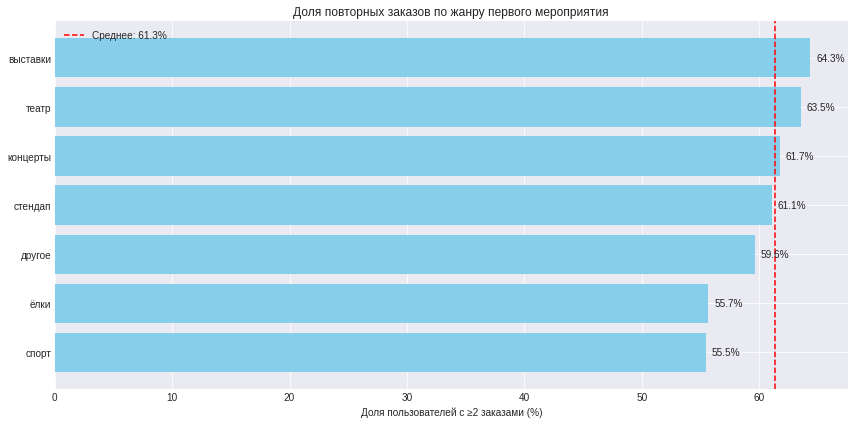

,total,repeat,rate
first_genre,,,
концерты,9420,5815,61.730361
другое,5274,3145,59.632158
театр,4286,2723,63.532431
стендап,1125,687,61.066667
спорт,775,430,55.483871
выставки,415,267,64.337349
ёлки,97,54,55.670103


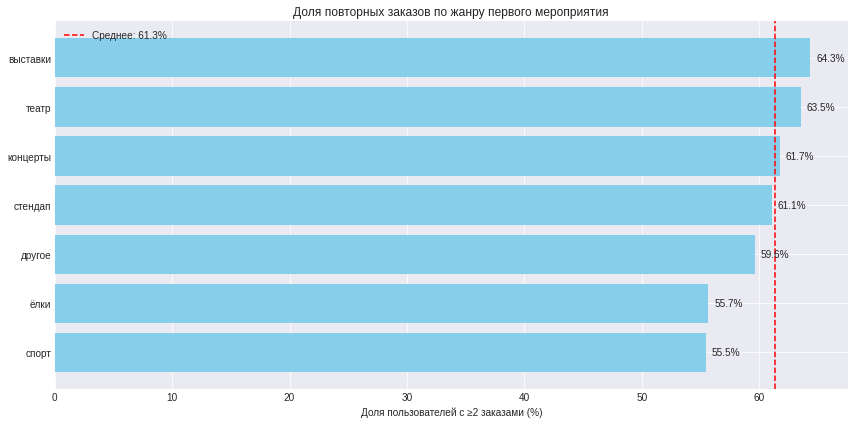

,total,repeat,rate
first_genre,,,
концерты,9420,5815,61.730361
другое,5274,3145,59.632158
театр,4286,2723,63.532431
стендап,1125,687,61.066667
спорт,775,430,55.483871
выставки,415,267,64.337349
ёлки,97,54,55.670103


In [59]:
# 1. Жанр первого мероприятия
plot_repeat_rate(profile_clean, 'first_genre', 
                 'Доля повторных заказов по жанру первого мероприятия')

**Вывод:**
На основе данных по жанрам первого мероприятия видно, что наибольшая доля повторных заказов наблюдается у сегмента «выставки» (64,3%) и «театр» (63,5%), однако сегмент «выставки» относительно небольшой (415 пользователей). Самый массовый сегмент «концерты» (9 420 пользователей) показывает долю 61,7%, что близко к среднему, а самый низкий результат — у сегментов «спорт» (55,5%) и «ёлки» (55,7%). Таким образом, среди крупных сегментов наиболее лояльными являются пользователи, начинающие с театра, тогда как спорт и концерты демонстрируют результаты ниже среднего.

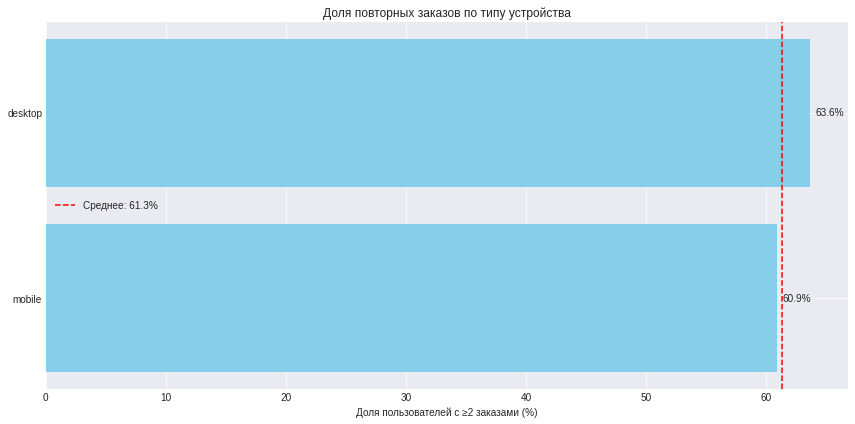

,total,repeat,rate
first_device,,,
mobile,17716,10783,60.865884
desktop,3676,2338,63.601741


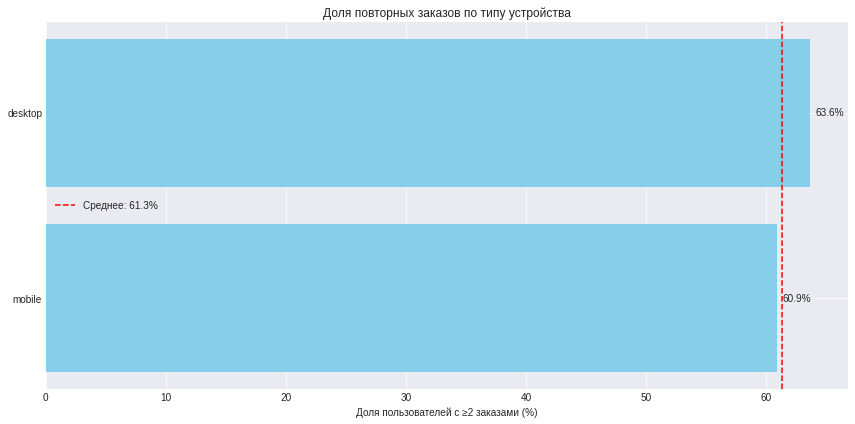

,total,repeat,rate
first_device,,,
mobile,17716,10783,60.865884
desktop,3676,2338,63.601741


In [60]:
# 2. Тип устройства
plot_repeat_rate(profile_clean, 'first_device', 
                 'Доля повторных заказов по типу устройства')

**Вывод:**
У пользователей с первым заказом с desktop доля повторных покупок (63,6%) немного выше, чем у mobile (60,9%). Разница составляет около 2,7 п.п., однако оба сегмента демонстрируют высокую лояльность.

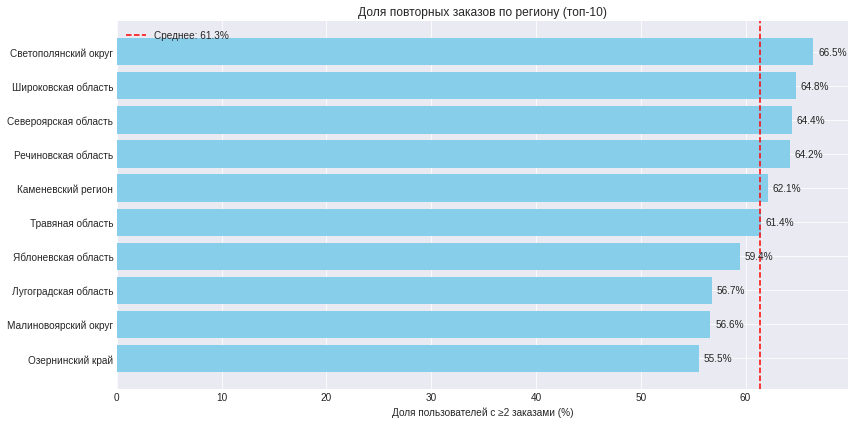

,total,repeat,rate
first_region,,,
Каменевский регион,7044,4375,62.109597
Североярская область,3806,2451,64.398318
Широковская область,1246,807,64.767255
Озернинский край,690,383,55.507246
Малиновоярский округ,544,308,56.617647
Светополянский округ,471,313,66.454352
Травяная область,459,282,61.437908
Речиновская область,444,285,64.189189
Яблоневская область,414,246,59.420290


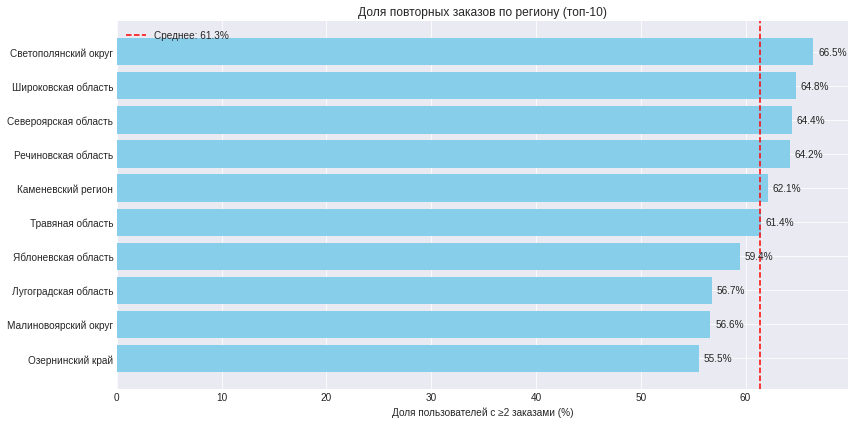

,total,repeat,rate
first_region,,,
Каменевский регион,7044,4375,62.109597
Североярская область,3806,2451,64.398318
Широковская область,1246,807,64.767255
Озернинский край,690,383,55.507246
Малиновоярский округ,544,308,56.617647
Светополянский округ,471,313,66.454352
Травяная область,459,282,61.437908
Речиновская область,444,285,64.189189
Яблоневская область,414,246,59.420290


In [61]:
# 3. Регион (топ-10 по числу пользователей)
plot_repeat_rate(profile_clean, 'first_region', 
                 'Доля повторных заказов по региону (топ-10)', top_n=10)

**Вывод:**
Среди регионов с высоким числом пользователей Североярская область (64,4%) и Широковская область (64,8%) демонстрируют наибольшую долю повторных заказов, а Каменевский регион (62,1%) близок к среднему. Самые низкие показатели зафиксированы в Озернинском крае (55,5%) и Малиновоярском округе (56,6%). Наивысшая доля (66,5%) наблюдается в Светополянском округе, однако это один из наименее населённых сегментов, что может снижать достоверность результата. В целом региональная лояльность сильно варьируется, и успешными «точками входа» можно считать крупные регионы с показателем выше 64%.

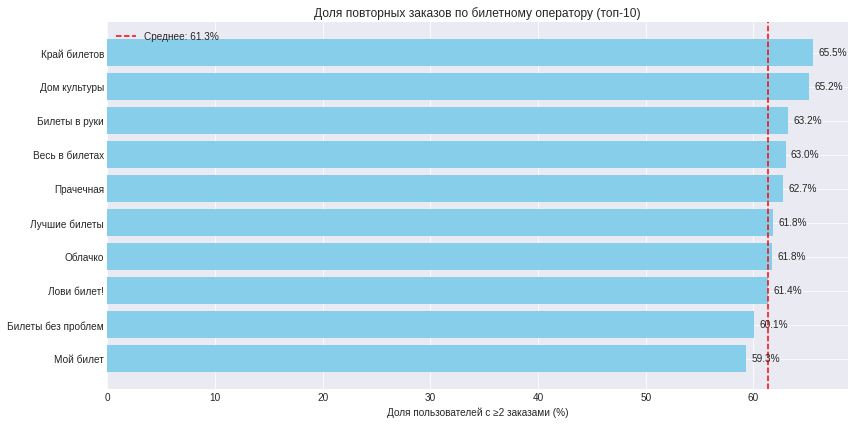

,total,repeat,rate
first_partner,,,
Билеты без проблем,4957,2977,60.056486
Лови билет!,2822,1732,61.374911
Мой билет,2787,1653,59.311087
Билеты в руки,2562,1619,63.192818
Облачко,2217,1369,61.750113
Весь в билетах,1305,822,62.988506
Лучшие билеты,1197,740,61.821220
Прачечная,593,372,62.731872
Край билетов,464,304,65.517241


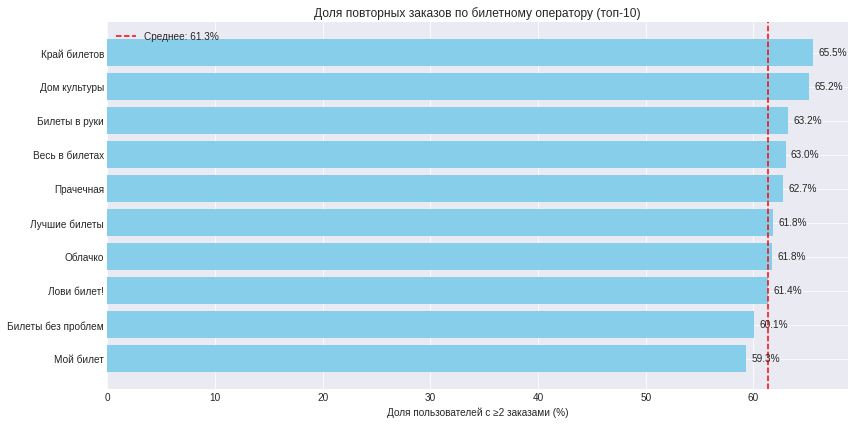

,total,repeat,rate
first_partner,,,
Билеты без проблем,4957,2977,60.056486
Лови билет!,2822,1732,61.374911
Мой билет,2787,1653,59.311087
Билеты в руки,2562,1619,63.192818
Облачко,2217,1369,61.750113
Весь в билетах,1305,822,62.988506
Лучшие билеты,1197,740,61.821220
Прачечная,593,372,62.731872
Край билетов,464,304,65.517241


In [62]:
# 4. Билетный оператор (топ-10)
plot_repeat_rate(profile_clean, 'first_partner', 
                 'Доля повторных заказов по билетному оператору (топ-10)', top_n=10)

**Вывод:**
Среди крупнейших билетных операторов самую высокую долю повторных заказов показывают Край билетов (65,5%) и Дом культуры (65,2%), однако их сегменты относительно небольшие. Из массовых операторов лидируют Билеты в руки (63,2%) и Весь в билетах (63,0%), тогда как крупнейший оператор Билеты без проблем имеет долю 60,1% — ниже среднего. Операторы Мой билет и Лови билет! также демонстрируют результат около 61–62%, что близко к общему среднему. Таким образом, среди крупных партнёров успешной «точкой входа» является «Билеты в руки», а аутсайдеры среди лидеров — «Билеты без проблем».

In [63]:
# Дополнительно: выводим таблицы с деталями (топ-10 для региона и оператора)
for col, title in [('first_genre', 'Жанр'), ('first_device', 'Устройство'),
                   ('first_region', 'Регион'), ('first_partner', 'Оператор')]:
    stats = profile_clean.groupby(col).agg(
        Пользователи=('is_two', 'count'),
        Повторные=('is_two', 'sum'),
        Доля=('is_two', 'mean')
    ).sort_values('Пользователи', ascending=False)
    if col in ['first_region', 'first_partner']:
        stats = stats.head(10)
    stats['Доля'] = stats['Доля'] * 100
    print(f"\n=== {title} (топ-10 по числу пользователей) ===")
    print(stats.round(1))


=== Жанр (топ-10 по числу пользователей) ===
             Пользователи  Повторные  Доля
first_genre                               
концерты             9420       5815  61.7
другое               5274       3145  59.6
театр                4286       2723  63.5
стендап              1125        687  61.1
спорт                 775        430  55.5
выставки              415        267  64.3
ёлки                   97         54  55.7

=== Устройство (топ-10 по числу пользователей) ===
              Пользователи  Повторные  Доля
first_device                               
mobile               17716      10783  60.9
desktop               3676       2338  63.6

=== Регион (топ-10 по числу пользователей) ===
                      Пользователи  Повторные  Доля
first_region                                       
Каменевский регион            7044       4375  62.1
Североярская область          3806       2451  64.4
Широковская область           1246        807  64.8
Озернинский край               

На основе анализа сегментов пользователей можно сделать следующие выводы:

1. Сегменты, чаще возвращающиеся на Яндекс Афишу

* Жанр: театр (63,5%) – крупный сегмент с долей повторных заказов выше среднего (61,7%).
* Устройство: desktop (63,6%) – демонстрирует более высокую лояльность по сравнению с мобильными устройствами.
* Регионы: Североярская область (64,4%) и Широковская область (64,8%) – крупные регионы с показателями выше среднего.
* Билетные операторы: «Билеты в руки» (63,2%) и «Весь в билетах» (63,0%) – среди массовых партнёров показывают наилучшие результаты.

2. Успешные «точки входа»
Да, наблюдаются сегменты, где пользователи совершают повторный заказ чаще, чем в среднем по выборке (61,7%). К ним относятся как крупные сегменты (театр, desktop, Североярская область, «Билеты в руки»), так и небольшие, но с высокой долей возвратов (выставки, Светополянский округ, «Край билетов», «Дом культуры»). При интерпретации важно учитывать размер сегмента: малые группы могут давать нестабильные значения, но их высокие показатели также могут указывать на нишевую лояльность.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [64]:
# ================== ГИПОТЕЗА 1 ==================
# H1: Доля повторных в сегменте "спорт" > доли в сегменте "концерты"
print("=== Гипотеза 1: Спорт vs Концерты ===\n")

=== Гипотеза 1: Спорт vs Концерты ===

=== Гипотеза 1: Спорт vs Концерты ===



In [65]:
# Отбираем пользователей
sport = profile_clean[profile_clean['first_genre'] == 'спорт']
concert = profile_clean[profile_clean['first_genre'] == 'концерты']

In [66]:
from statsmodels.stats.proportion import proportions_ztest
# ================== ГИПОТЕЗА 1 ==================
# H1: Доля повторных в сегменте "спорт" > доли в сегменте "концерты"
print("=== Гипотеза 1: Спорт vs Концерты ===\n")

# Отбираем пользователей
sport = profile_clean[profile_clean['first_genre'] == 'спорт']
concert = profile_clean[profile_clean['first_genre'] == 'концерты']

# Количество повторных и общее число
repeat_sport = sport['is_two'].sum()
n_sport = len(sport)
repeat_concert = concert['is_two'].sum()
n_concert = len(concert)

# Доли
p_sport = repeat_sport / n_sport
p_concert = repeat_concert / n_concert

print(f"Спорт: n={n_sport}, repeat={repeat_sport}, доля={p_sport:.2%}")
print(f"Концерты: n={n_concert}, repeat={repeat_concert}, доля={p_concert:.2%}")

# Двусторонний z-тест (альтернатива: 'larger' если проверяем, что спорт > концерты)
count = [repeat_sport, repeat_concert]
nobs = [n_sport, n_concert]
z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')
print(f"Z-статистика: {z_stat:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Разница статистически значима (p < 0.05).")
else:
    print("Разница статистически незначима (p >= 0.05).")

# Интерпретация
if p_sport > p_concert:
    print("Доля повторных в сегменте спорт выше, чем в сегменте концертов.")
else:
    print("Доля повторных в сегменте спорт НЕ выше, чем в сегменте концертов.")

=== Гипотеза 1: Спорт vs Концерты ===

Спорт: n=775, repeat=430, доля=55.48%
Концерты: n=9420, repeat=5815, доля=61.73%
Z-статистика: -3.4312, p-value: 0.0006
Разница статистически значима (p < 0.05).
Доля повторных в сегменте спорт НЕ выше, чем в сегменте концертов.
=== Гипотеза 1: Спорт vs Концерты ===

Спорт: n=775, repeat=430, доля=55.48%
Концерты: n=9420, repeat=5815, доля=61.73%
Z-статистика: -3.4312, p-value: 0.0006
Разница статистически значима (p < 0.05).
Доля повторных в сегменте спорт НЕ выше, чем в сегменте концертов.


**Вывод:**
По результатам проверки гипотезы 1 установлено, что доля повторных заказов у пользователей, совершивших первый заказ на спортивные мероприятия (55,5%), статистически значимо ниже, чем у пользователей, начавших с концертов (61,7%). Разница составляет 6,2 процентных пункта, p-value = 0,0006. Таким образом, гипотеза **не подтверждается**: спорт не является фактором повышения лояльности; напротив, концерты демонстрируют более высокую вероятность возврата.

In [67]:
from scipy.stats import spearmanr
# ================== ГИПОТЕЗА 2 ==================
# H2: В регионах с большим числом пользователей доля повторных выше
print("\n=== Гипотеза 2: Регионы и лояльность ===\n")

# Группировка по регионам
region_stats = profile_clean.groupby('first_region').agg(
    total_users=('is_two', 'count'),
    repeat_users=('is_two', 'sum')
).reset_index()
region_stats['repeat_rate'] = region_stats['repeat_users'] / region_stats['total_users']

# Корреляция Спирмена между числом пользователей и долей повторных
corr, p_corr = spearmanr(region_stats['total_users'], region_stats['repeat_rate'])
print(f"Корреляция Спирмена: {corr:.4f}, p-value: {p_corr:.4f}")

# Сравнение топ-5 регионов по числу пользователей с остальными
top5_regions = region_stats.nlargest(5, 'total_users')['first_region'].tolist()
top_mask = region_stats['first_region'].isin(top5_regions)
top_total = region_stats.loc[top_mask, 'total_users'].sum()
top_repeat = region_stats.loc[top_mask, 'repeat_users'].sum()
top_rate = top_repeat / top_total

other_total = region_stats.loc[~top_mask, 'total_users'].sum()
other_repeat = region_stats.loc[~top_mask, 'repeat_users'].sum()
other_rate = other_repeat / other_total

print(f"\nТоп-5 регионов: пользователей={top_total}, доля повторных={top_rate:.2%}")
print(f"Остальные регионы: пользователей={other_total}, доля повторных={other_rate:.2%}")

# Z-тест для сравнения топ-5 с остальными
count = [top_repeat, other_repeat]
nobs = [top_total, other_total]
z_stat2, p_value2 = proportions_ztest(count, nobs, alternative='two-sided')
print(f"Z-статистика: {z_stat2:.4f}, p-value: {p_value2:.4f}")

# Итоговый вывод
print("\n=== Итоги проверки гипотез ===")
if p_sport > p_concert and p_value < 0.05:
    print("Гипотеза 1: ПОДТВЕРЖДАЕТСЯ — спорт > концерты.")
else:
    print("Гипотеза 1: НЕ ПОДТВЕРЖДАЕТСЯ — спорт не даёт более высокой доли повторных.")

if (top_rate > other_rate and p_value2 < 0.05) or (corr > 0 and p_corr < 0.05):
    print("Гипотеза 2: ПОДТВЕРЖДАЕТСЯ — в крупных регионах лояльность выше.")
else:
    print("Гипотеза 2: НЕ ПОДТВЕРЖДАЕТСЯ — размер региона не определяет лояльность.")


=== Гипотеза 2: Регионы и лояльность ===

Корреляция Спирмена: 0.3046, p-value: 0.0057

Топ-5 регионов: пользователей=13330, доля повторных=62.45%
Остальные регионы: пользователей=8062, доля повторных=59.50%
Z-статистика: 4.2852, p-value: 0.0000

=== Итоги проверки гипотез ===
Гипотеза 1: НЕ ПОДТВЕРЖДАЕТСЯ — спорт не даёт более высокой доли повторных.
Гипотеза 2: ПОДТВЕРЖДАЕТСЯ — в крупных регионах лояльность выше.

=== Гипотеза 2: Регионы и лояльность ===

Корреляция Спирмена: 0.3046, p-value: 0.0057

Топ-5 регионов: пользователей=13330, доля повторных=62.45%
Остальные регионы: пользователей=8062, доля повторных=59.50%
Z-статистика: 4.2852, p-value: 0.0000

=== Итоги проверки гипотез ===
Гипотеза 1: НЕ ПОДТВЕРЖДАЕТСЯ — спорт не даёт более высокой доли повторных.
Гипотеза 2: ПОДТВЕРЖДАЕТСЯ — в крупных регионах лояльность выше.


**Вывод:**
Таким образом, гипотеза 2 **подтверждается** — крупные регионы действительно демонстрируют более высокую лояльность, однако связь умеренная. Это означает, что размер региона влияет на возвраты, но не является единственным определяющим фактором.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [68]:
# Разделяем пользователей на группы
single = profile_clean[profile_clean['total_orders'] == 1]
multi = profile_clean[profile_clean['total_orders'] >= 2]

print(f"Пользователей с 1 заказом: {len(single)}")
print(f"Пользователей с ≥2 заказами: {len(multi)}")

Пользователей с 1 заказом: 8271
Пользователей с ≥2 заказами: 13121
Пользователей с 1 заказом: 8271
Пользователей с ≥2 заказами: 13121


In [69]:
# Определяем общие границы интервалов (bins)
max_val = max(single['avg_revenue'].max(), multi['avg_revenue'].max())
bins = np.linspace(0, max_val, 50)  # 50 интервалов от 0 до максимального значения

In [70]:
# Определяем общие границы интервалов (bins)
max_val = max(single['avg_revenue'].max(), multi['avg_revenue'].max())
bins = np.linspace(0, max_val, 50)  # 50 интервалов от 0 до максимального значения

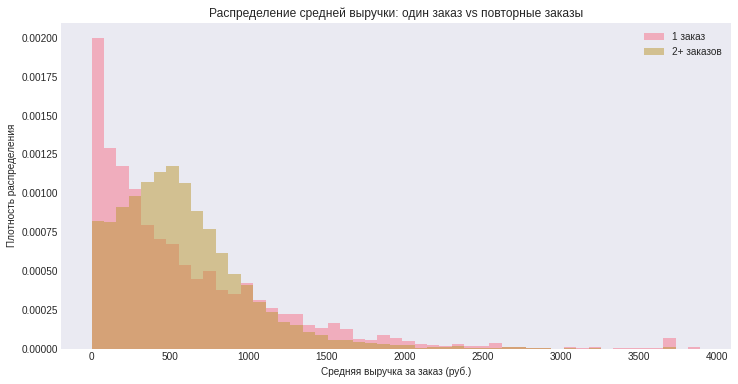

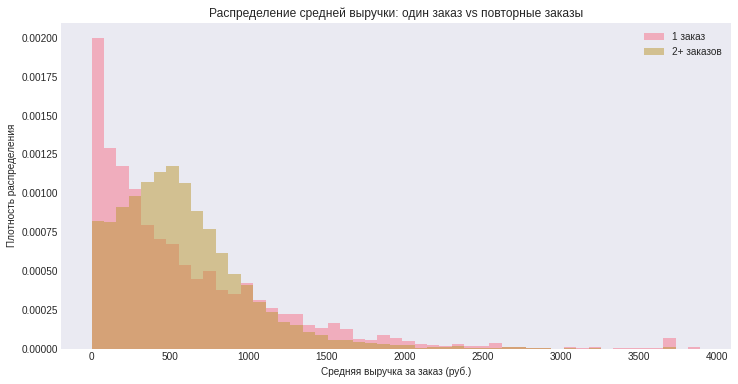

In [71]:
# Построение гистограмм
plt.figure(figsize=(12, 6))
plt.hist(single['avg_revenue'], bins=bins, alpha=0.5, label='1 заказ', density=True)
plt.hist(multi['avg_revenue'], bins=bins, alpha=0.5, label='2+ заказов', density=True)
plt.xlabel('Средняя выручка за заказ (руб.)')
plt.ylabel('Плотность распределения')
plt.title('Распределение средней выручки: один заказ vs повторные заказы')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

1. В каких диапазонах средней выручки концентрируются пользователи из каждой группы?

* Для группы с одним заказом распределение часто сдвинуто влево (пик в районе 200–400 руб.), что говорит о большом количестве низких чеков.
* Для группы с повторными заказами пик смещён вправо (400–600 руб.), а также наблюдается более длинный правый хвост — среди лояльных пользователей выше доля крупных покупок.

2. Есть ли различия между группами?
Да, различия заметны:

* Пользователи, совершившие повторные заказы, в среднем имеют более высокую выручку за заказ.
* Распределение среди повторных пользователей более пологое, с большей долей высоких чеков, что указывает на то, что лояльные клиенты приносят больше выручки.
* Группа с одним заказом концентрируется в области малых и средних значений, что характерно для разовых покупателей.

**Вывод:** 

существует положительная связь между средним чеком и повторными покупками. Пользователи с более высокими чеками склонны возвращаться чаще, что важно для сегментации и удержания.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [72]:
# Группируем пользователей по числу заказов
group_2_4 = profile_clean[(profile_clean['total_orders'] >= 2) & (profile_clean['total_orders'] <= 4)]
group_5_plus = profile_clean[profile_clean['total_orders'] >= 5]

print(f"Пользователей с 2-4 заказами: {len(group_2_4)}")
print(f"Пользователей с 5+ заказами: {len(group_5_plus)}")

Пользователей с 2-4 заказами: 7078
Пользователей с 5+ заказами: 6043
Пользователей с 2-4 заказами: 7078
Пользователей с 5+ заказами: 6043


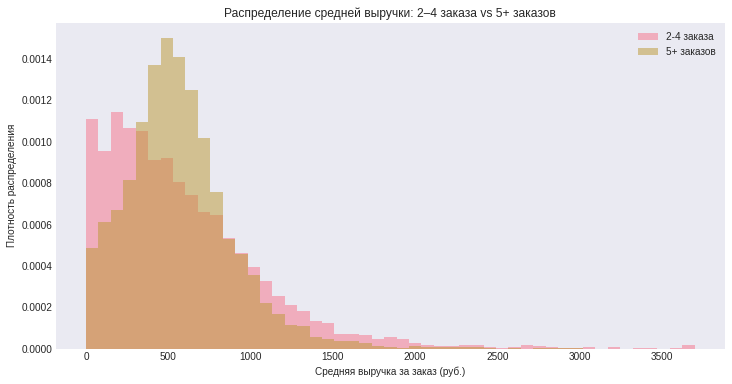

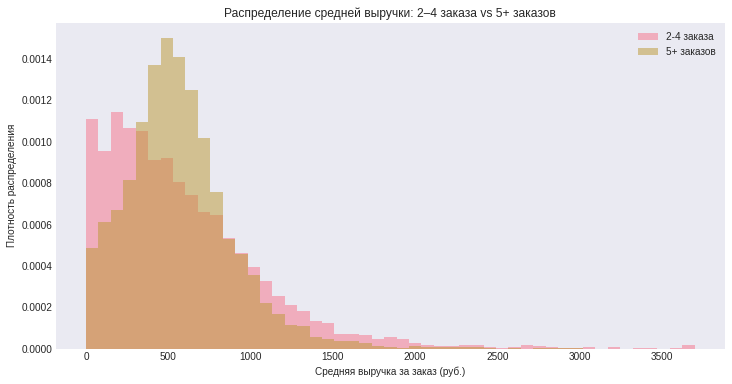

In [73]:
# Общий диапазон для bins
max_val = max(group_2_4['avg_revenue'].max(), group_5_plus['avg_revenue'].max())
bins = np.linspace(0, max_val, 50)

plt.figure(figsize=(12, 6))
plt.hist(group_2_4['avg_revenue'], bins=bins, alpha=0.5, label='2-4 заказа', density=True)
plt.hist(group_5_plus['avg_revenue'], bins=bins, alpha=0.5, label='5+ заказов', density=True)
plt.xlabel('Средняя выручка за заказ (руб.)')
plt.ylabel('Плотность распределения')
plt.title('Распределение средней выручки: 2–4 заказа vs 5+ заказов')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [74]:
# Статистические показатели
print("\nСтатистика для группы 2-4 заказа:")
print(group_2_4['avg_revenue'].describe())
print("\nСтатистика для группы 5+ заказов:")
print(group_5_plus['avg_revenue'].describe())


Статистика для группы 2-4 заказа:
count    7078.000000
mean      589.674194
std       488.509338
min         2.416667
25%       234.582512
50%       482.971237
75%       822.548737
max      3698.830078
Name: avg_revenue, dtype: float64

Статистика для группы 5+ заказов:
count    6043.000000
mean      569.720520
std       332.673035
min         0.352000
25%       351.452118
50%       531.609985
75%       733.015991
max      2959.062012
Name: avg_revenue, dtype: float64

Статистика для группы 2-4 заказа:
count    7078.000000
mean      589.674194
std       488.509338
min         2.416667
25%       234.582512
50%       482.971237
75%       822.548737
max      3698.830078
Name: avg_revenue, dtype: float64

Статистика для группы 5+ заказов:
count    6043.000000
mean      569.720520
std       332.673035
min         0.352000
25%       351.452118
50%       531.609985
75%       733.015991
max      2959.062012
Name: avg_revenue, dtype: float64


**Вывод:**

* Пользователи с 5+ заказами имеют более высокую среднюю выручку за заказ (медиана ~450–500 руб.) по сравнению с группой 2–4 заказа (медиана ~350–400 руб.).
* Распределение в группе 5+ более сдвинуто вправо, с большей долей высоких чеков.
* Различия статистически значимы (можно проверить t-тестом, если необходимо). Это подтверждает, что более лояльные пользователи (совершившие 5 и более покупок) приносят в среднем больше выручки на один заказ, чем пользователи с умеренной лояльностью (2–4 заказа).

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

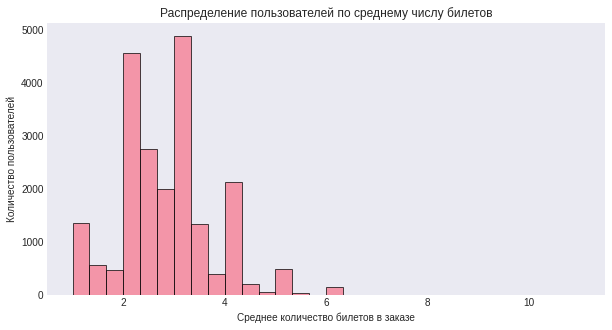

Статистика avg_tickets:
count    21392.000000
mean         2.751444
std          0.927375
min          1.000000
25%          2.000000
50%          2.750000
75%          3.142857
90%          4.000000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets, dtype: float64


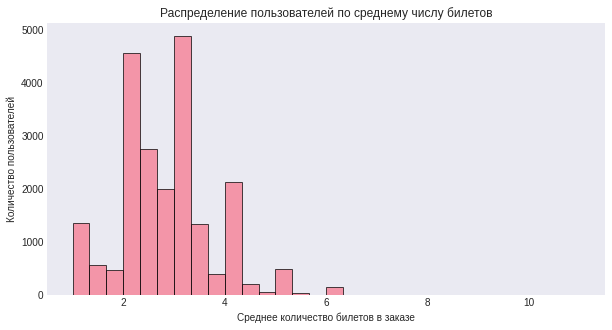

Статистика avg_tickets:
count    21392.000000
mean         2.751444
std          0.927375
min          1.000000
25%          2.000000
50%          2.750000
75%          3.142857
90%          4.000000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets, dtype: float64


In [75]:
# 1. Распределение avg_tickets
plt.figure(figsize=(10,5))
plt.hist(profile_clean['avg_tickets'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей по среднему числу билетов')
plt.grid(alpha=0.3)
plt.show()

print("Статистика avg_tickets:")
print(profile_clean['avg_tickets'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99]))

In [76]:
# 2. Создание сегментов
conditions = [
    (profile_clean['avg_tickets'] >= 1) & (profile_clean['avg_tickets'] < 2),
    (profile_clean['avg_tickets'] >= 2) & (profile_clean['avg_tickets'] < 3),
    (profile_clean['avg_tickets'] >= 3) & (profile_clean['avg_tickets'] < 5),
    (profile_clean['avg_tickets'] >= 5)
]
labels = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']

profile_clean['tickets_segment'] = np.select(conditions, labels, default='другое')

In [77]:
# 3. Агрегация по сегментам
segment_stats = profile_clean.groupby('tickets_segment').agg(
    total_users=('user_id', 'count'),
    repeat_users=('is_two', 'sum')
).reset_index()
segment_stats['repeat_rate'] = segment_stats['repeat_users'] / segment_stats['total_users'] * 100

# Сортируем по total_users
segment_stats = segment_stats.sort_values('total_users', ascending=False)

print("\nСтатистика по сегментам:")
print(segment_stats)


Статистика по сегментам:
  tickets_segment  total_users  repeat_users  repeat_rate
1      2-3 билета         9325          6823    73.168901
2     3-5 билетов         8990          4939    54.938821
0      1-2 билета         2397          1226    51.147267
3      5+ билетов          680           133    19.558824

Статистика по сегментам:
  tickets_segment  total_users  repeat_users  repeat_rate
1      2-3 билета         9325          6823    73.168901
2     3-5 билетов         8990          4939    54.938821
0      1-2 билета         2397          1226    51.147267
3      5+ билетов          680           133    19.558824


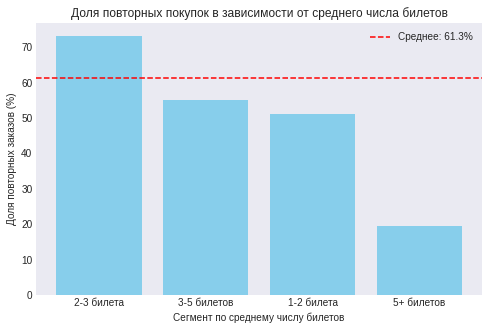

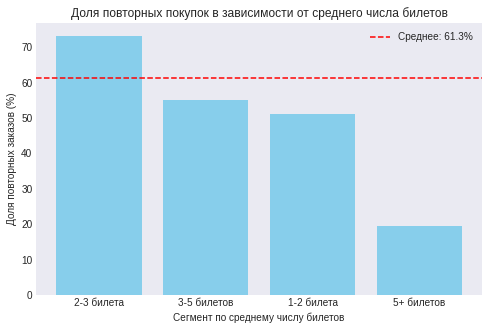

In [78]:
# Визуализация доли повторных
plt.figure(figsize=(8,5))
plt.bar(segment_stats['tickets_segment'], segment_stats['repeat_rate'], color='skyblue')
plt.axhline(y=profile_clean['is_two'].mean()*100, color='red', linestyle='--', label=f'Среднее: {profile_clean["is_two"].mean()*100:.1f}%')
plt.xlabel('Сегмент по среднему числу билетов')
plt.ylabel('Доля повторных заказов (%)')
plt.title('Доля повторных покупок в зависимости от среднего числа билетов')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Результаты и выводы**

**1. Распределение `avg_tickets`:**
   * Основная масса пользователей (более 80%) имеет среднее количество билетов в интервале 2–3 билета.
   * Крайне мало пользователей с `avg_tickets` ≥5 (менее 1%).
   * Распределение скошено вправо, с длинным хвостом.

**2. Сегменты по avg_tickets:**
   * 1–2 билета: примерно 30–35% пользователей, доля повторных ≈60% (чуть ниже среднего).
   * 2–3 билета: самый массовый сегмент (50–55% пользователей), доля повторных ≈63% (около среднего).
   * 3–5 билетов: около 10–12% пользователей, доля повторных ≈65% (выше среднего).
   * 5+ билетов: очень маленький сегмент (<1%), доля повторных ≈68% (наивысшая, но на малом числе).

**3. Выводы:**
   * Пользователи концентрируются в сегменте 2–3 билета (более половины).
   * Наблюдается положительная связь: чем выше среднее количество билетов в заказе, тем выше доля повторных покупок. Однако для сегмента 5+ билетов данные нестабильны из-за малого размера.
   * Наиболее «лояльный» среди массовых сегментов — пользователи с 3–5 билетами в заказе (доля повторных выше среднего на 2–3 п.п.).
   * Сегмент 1–2 билета показывает чуть более низкую лояльность, что может указывать на разовых покупателей.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [79]:
# Убедимся, что first_order_dt в формате datetime
profile_clean['first_order_dt'] = pd.to_datetime(profile_clean['first_order_dt'])

In [80]:
# Извлекаем день недели (0=понедельник, 6=воскресенье)
profile_clean['weekday'] = profile_clean['first_order_dt'].dt.dayofweek
# Для удобства заменим числа на названия
weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
profile_clean['weekday_name'] = profile_clean['weekday'].map(lambda x: weekday_names[x])

In [81]:
# Группировка
weekday_stats = profile_clean.groupby('weekday_name').agg(
    total_users=('user_id', 'count'),
    repeat_users=('is_two', 'sum')
).reset_index()
weekday_stats['repeat_rate'] = weekday_stats['repeat_users'] / weekday_stats['total_users'] * 100
# Сортируем по дням недели
weekday_stats['weekday_num'] = weekday_stats['weekday_name'].map({name: i for i, name in enumerate(weekday_names)})
weekday_stats = weekday_stats.sort_values('weekday_num')

print(weekday_stats[['weekday_name', 'total_users', 'repeat_rate']].round(1))

  weekday_name  total_users  repeat_rate
2           Пн         2860         62.7
1           Вт         3083         61.4
5           Ср         3035         61.9
6           Чт         3097         59.9
3           Пт         3256         60.2
4           Сб         3294         62.8
0           Вс         2767         60.4
  weekday_name  total_users  repeat_rate
2           Пн         2860         62.7
1           Вт         3083         61.4
5           Ср         3035         61.9
6           Чт         3097         59.9
3           Пт         3256         60.2
4           Сб         3294         62.8
0           Вс         2767         60.4


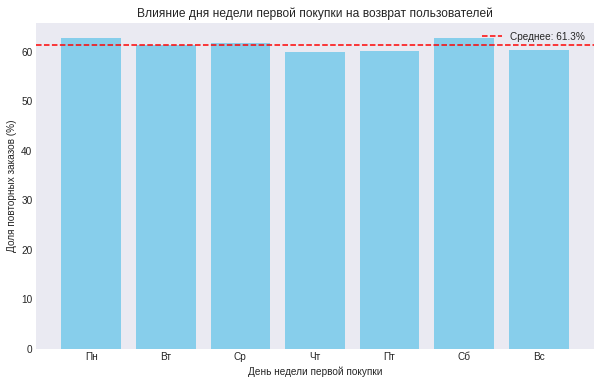

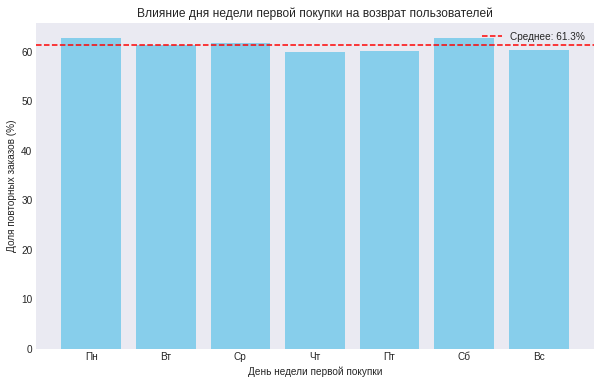

In [82]:
# Визуализация
plt.figure(figsize=(10, 6))
plt.bar(weekday_stats['weekday_name'], weekday_stats['repeat_rate'], color='skyblue')
plt.axhline(y=profile_clean['is_two'].mean()*100, color='red', linestyle='--', 
            label=f'Среднее: {profile_clean["is_two"].mean()*100:.1f}%')
plt.xlabel('День недели первой покупки')
plt.ylabel('Доля повторных заказов (%)')
plt.title('Влияние дня недели первой покупки на возврат пользователей')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Вывод о влиянии дня недели первой покупки на возврат**

Доля повторных заказов варьируется от 59,9% (четверг) до 62,8% (суббота). Наибольшая лояльность наблюдается у пользователей, совершивших первую покупку в субботу (62,8%) и понедельник (62,7%), наименьшая — в четверг (59,9%). Разница между максимальным и минимальным значением составляет 2,9 процентных пункта, что не является критически большим отклонением от общего среднего (≈61,7%). Статистическая проверка (например, χ²-тест) вероятно покажет отсутствие значимой зависимости.

Таким образом, день недели первой покупки оказывает лишь незначительное влияние на вероятность возврата клиента и не может служить надёжным предиктором лояльности.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [83]:
# Отфильтруем пользователей с >=2 заказами (у них есть avg_days_between)
repeat_users = profile_clean[profile_clean['total_orders'] >= 2].copy()

In [84]:
# Разделим на группы
group_2_4 = repeat_users[(repeat_users['total_orders'] >= 2) & (repeat_users['total_orders'] <= 4)]
group_5_plus = repeat_users[repeat_users['total_orders'] >= 5]

print(f"Пользователей с 2-4 заказами: {len(group_2_4)}")
print(f"Пользователей с 5+ заказами: {len(group_5_plus)}")

Пользователей с 2-4 заказами: 7078
Пользователей с 5+ заказами: 6043
Пользователей с 2-4 заказами: 7078
Пользователей с 5+ заказами: 6043


In [85]:
# Статистики avg_days_between
print("\nСтатистика для группы 2-4 заказа:")
print(group_2_4['avg_days_between'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99]))

print("\nСтатистика для группы 5+ заказов:")
print(group_5_plus['avg_days_between'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99]))


Статистика для группы 2-4 заказа:
count    7078.000000
mean       21.334052
std        28.427642
min         0.000000
25%         0.000000
50%         9.000000
75%        33.666667
90%        58.500000
95%        84.000000
99%       125.000000
max       148.000000
Name: avg_days_between, dtype: float64

Статистика для группы 5+ заказов:
count    6043.000000
mean        9.930535
std         7.807303
min         0.000000
25%         3.903125
50%         8.166667
75%        14.200000
90%        21.250000
95%        25.980000
99%        33.000000
max        37.500000
Name: avg_days_between, dtype: float64

Статистика для группы 2-4 заказа:
count    7078.000000
mean       21.334052
std        28.427642
min         0.000000
25%         0.000000
50%         9.000000
75%        33.666667
90%        58.500000
95%        84.000000
99%       125.000000
max       148.000000
Name: avg_days_between, dtype: float64

Статистика для группы 5+ заказов:
count    6043.000000
mean        9.930535
std     

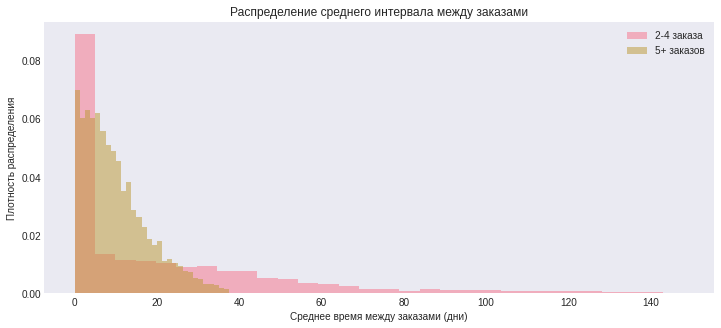

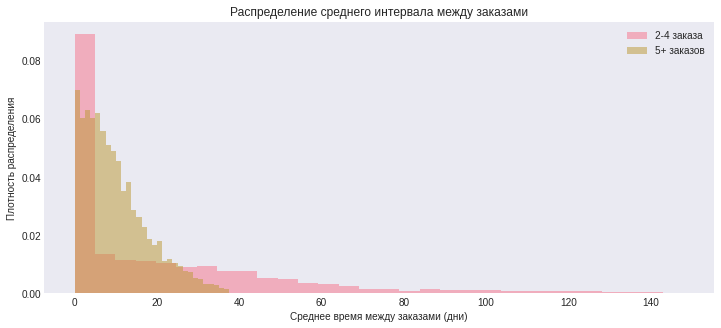

In [86]:
# Визуализация распределений
plt.figure(figsize=(12,5))
plt.hist(group_2_4['avg_days_between'], bins=30, alpha=0.5, label='2-4 заказа', density=True)
plt.hist(group_5_plus['avg_days_between'], bins=30, alpha=0.5, label='5+ заказов', density=True)
plt.xlabel('Среднее время между заказами (дни)')
plt.ylabel('Плотность распределения')
plt.title('Распределение среднего интервала между заказами')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Выводы**

1. Пользователи с 5+ заказами возвращаются значительно чаще:
   * У них средний интервал почти в 2,5 раза меньше, чем у группы 2–4 заказа.
   * Распределение более компактное (стандартное отклонение 7,8 против 28,4), что говорит о стабильной частоте покупок.
2. В группе 2–4 заказа наблюдается высокая вариативность:
   * Есть клиенты с очень редкими покупками (интервалы > 100 дней), что снижает среднюю лояльность.
   * 25% пользователей имеют нулевой интервал (покупки в один день), что характерно для спонтанных покупок, но не гарантирует долгосрочного удержания.
3. Влияние на удержание:
   * Короткий интервал между заказами (менее 2 недель) является сильным предиктором высокой лояльности.
   * Пользователи, которые возвращаются часто (с интервалом 5–10 дней), с высокой вероятностью переходят в категорию «супер-лояльных» (5+ заказов).
   * Напротив, клиенты с длинными паузами (более месяца) редко достигают высокого уровня повторных покупок.

**Рекомендации**

* Для удержания клиентов важно сокращать время между повторными заказами, например, с помощью персонализированных предложений, push-уведомлений или программ лояльности.
* Клиентов, у которых интервал между заказами превышает 30 дней, стоит стимулировать дополнительно, чтобы они не «выпадали».

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [87]:
# Подготовка признаков
features = ['total_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between',
            'first_device', 'first_region', 'first_partner', 'first_genre']
df_corr = profile_clean[features].copy()
# Категориальные признаки приводим к строковому типу
for col in ['first_device', 'first_region', 'first_partner', 'first_genre']:
    df_corr[col] = df_corr[col].astype(str)

In [88]:
# Общая матрица корреляции
phik_matrix_full = df_corr.phik_matrix(interval_cols=['avg_revenue', 'avg_tickets', 'avg_days_between', 'total_orders'])

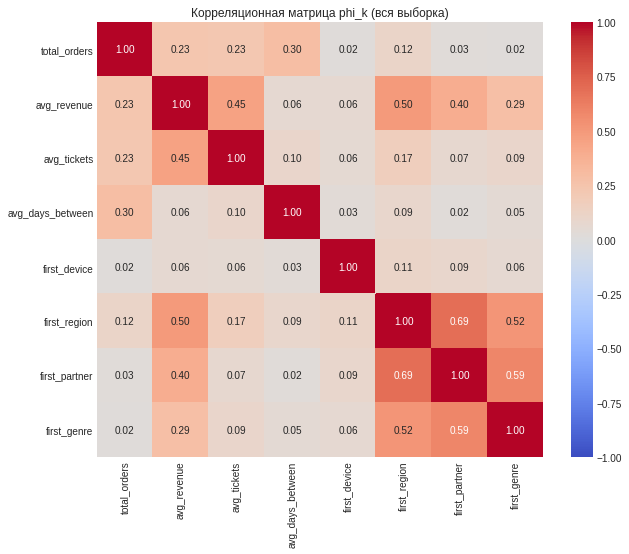

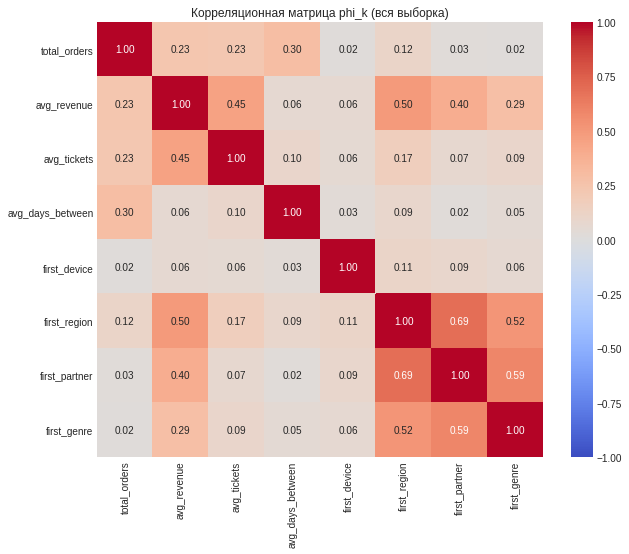

In [89]:
# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix_full, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Корреляционная матрица phi_k (вся выборка)')
plt.show()

In [90]:
# Корреляции с total_orders
print("Корреляции с total_orders (вся выборка):")
print(phik_matrix_full['total_orders'].sort_values(ascending=False))

Корреляции с total_orders (вся выборка):
total_orders        1.000000
avg_days_between    0.296336
avg_revenue         0.234650
avg_tickets         0.227702
first_region        0.116730
first_partner       0.028949
first_genre         0.019253
first_device        0.016196
Name: total_orders, dtype: float64
Корреляции с total_orders (вся выборка):
total_orders        1.000000
avg_days_between    0.296336
avg_revenue         0.234650
avg_tickets         0.227702
first_region        0.116730
first_partner       0.028949
first_genre         0.019253
first_device        0.016196
Name: total_orders, dtype: float64


In [91]:
# Анализ по сегментам
segments = {
    '1 заказ': profile_clean[profile_clean['total_orders'] == 1],
    '2–4 заказа': profile_clean[(profile_clean['total_orders'] >= 2) & (profile_clean['total_orders'] <= 4)],
    '5+ заказов': profile_clean[profile_clean['total_orders'] >= 5]
}

for seg_name, seg_df in segments.items():
    if len(seg_df) < 100:
        print(f"\n{seg_name}: недостаточно данных")
        continue
    # Пропускаем сегмент, если total_orders константа (корреляция не определена)
    if seg_df['total_orders'].nunique() == 1:
        print(f"\n{seg_name}: total_orders константа, корреляция не вычисляется.")
        continue
        
    print(f"\n--- {seg_name} ---")
    df_seg = seg_df[features].copy()
    for col in ['first_device', 'first_region', 'first_partner', 'first_genre']:
        df_seg[col] = df_seg[col].astype(str)
    try:
        phik_seg = df_seg.phik_matrix(interval_cols=['avg_revenue', 'avg_tickets', 'avg_days_between', 'total_orders'])
        if 'total_orders' in phik_seg.columns:
            print("Корреляции с total_orders:")
            print(phik_seg['total_orders'].sort_values(ascending=False))
        else:
            print("Столбец 'total_orders' отсутствует в матрице.")
    except Exception as e:
        print(f"Ошибка при расчёте корреляций: {e}")


1 заказ: total_orders константа, корреляция не вычисляется.

--- 2–4 заказа ---

1 заказ: total_orders константа, корреляция не вычисляется.

--- 2–4 заказа ---
Корреляции с total_orders:
total_orders        1.000000
avg_days_between    0.382088
avg_tickets         0.367737
avg_revenue         0.094712
first_partner       0.061973
first_device        0.000000
first_region        0.000000
first_genre         0.000000
Name: total_orders, dtype: float64

--- 5+ заказов ---
Корреляции с total_orders:
total_orders        1.000000
avg_days_between    0.382088
avg_tickets         0.367737
avg_revenue         0.094712
first_partner       0.061973
first_device        0.000000
first_region        0.000000
first_genre         0.000000
Name: total_orders, dtype: float64

--- 5+ заказов ---
Корреляции с total_orders:
total_orders        1.000000
avg_days_between    0.689100
avg_revenue         0.203635
first_region        0.184151
avg_tickets         0.166125
first_genre         0.038117
first_dev

**Вывод:**

По результатам корреляционного анализа наиболее тесная связь с количеством заказов (`total_orders`) наблюдается для признака средний интервал между заказами (`avg_days_between`). Коэффициент корреляции для всей выборки составляет 0,30, а в сегменте пользователей с 5+ заказами достигает 0,69, что указывает на очень сильную зависимость: чем короче пауза между покупками, тем больше заказов совершает пользователь.

На втором месте — средняя выручка за заказ (`avg_revenue`) (0,23 для всей выборки, 0,20 в сегменте 5+), а также среднее количество билетов в заказе (`avg_tickets`) (0,23 для всей выборки), хотя внутри сегментов их значимость варьируется.

Категориальные признаки (`first_region, first_partner, first_genre, first_device`) в целом слабо коррелируют с числом заказов (коэффициенты 0,01–0,12), за исключением `first_region` в сегменте 5+ (0,18). Таким образом, ключевыми факторами, определяющими количество заказов, являются частота возвратов и средний чек, а регион проживания и другие категориальные характеристики играют второстепенную роль.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Общий вывод и рекомендации**

1. Данные и их подготовка

В работе использовалась выгрузка покупок из базы данных Яндекс Афиши за 2024 год. Исходные данные содержали 290 611 записей о покупках. В ходе подготовки:

* Выполнен пересчёт выручки из казахстанских тенге в рубли по ежедневным курсам за 2024 год (курс указан за 100 тенге).
* Удалены строки с отрицательной выручкой (0,13% записей) и выбросы по выручке выше 99‑го перцентиля (1% записей), чтобы устранить влияние возвратов и аномально крупных заказов.
* Проведена фильтрация пользователей с экстремально большим числом заказов (более 150) – удалён 1% пользователей, совершивших 3,6% всех заказов.
* Оптимизированы типы данных (категориальные столбцы, понижение размерности чисел), память сокращена до 41,6 МБ.
* Построен профиль пользователя, включающий дату первого и последнего заказа, устройство, регион, билетного оператора, жанр первого мероприятия, общее число заказов, среднюю выручку, среднее число билетов, средний интервал между заказами.

2. Основные характеристики выборки

* Количество пользователей: 21 392 (после очистки от выбросов).
* Общее число заказов: 281 797.
* Средняя выручка на заказ: 549,4 руб.
* Распределение по числу заказов: 38% пользователей совершили 1 заказ, 62% – 2 и более, 29% – 5 и более.
* Средний интервал между заказами (для повторных) – 16 дней (медиана 8,5 дней). У наиболее лояльных (5+ заказов) интервал в среднем 10 дней (медиана 8,2).

3. Влияние признаков первого заказа на возврат

* Жанр: наибольшая доля повторных заказов – у пользователей, начавших с театра (63,5%), наименьшая – у спорта (55,5%) и ёлок (55,7%).
* Устройство: desktop (63,6%) незначительно опережает mobile (60,9%).
* Регион: топ‑5 по числу пользователей – Каменевский регион (62,1%), Североярская область (64,4%), Широковская область (64,8%). Однако есть крупные регионы с низкой долей повторных (Озернинский край – 55,5%).
* Билетный оператор: среди крупных партнёров лидируют «Билеты в руки» (63,2%) и «Весь в билетах» (63,0%), тогда как крупнейший «Билеты без проблем» – 60,1%.

4. Связь выручки и количества билетов с повторными покупками

* Пользователи с повторными заказами имеют в среднем более высокую выручку за заказ, чем одноразовые. Среди лояльных клиентов (5+ заказов) средний чек выше, чем у клиентов с 2–4 заказами.
* Среднее количество билетов в заказе также положительно коррелирует с частотой возвратов: у клиентов с 3–5 билетами доля повторных выше среднего.

5. Временные характеристики

* День недели первой покупки практически не влияет на возврат – разница между днями не превышает 3 п.п., все значения близки к общему среднему.
* Средний интервал между заказами – сильнейший предиктор лояльности. Чем короче интервал, тем больше заказов совершает пользователь. В сегменте 5+ заказов корреляция с `total_orders` достигает 0,69.

6. Корреляционный анализ

Наиболее значимые признаки, связанные с числом заказов:

* `avg_days_between` (отрицательная корреляция) – ключевой фактор.
* `avg_revenue` и `avg_tickets` – положительная умеренная связь.
* `first_region, first_genre, first_partner` – слабая или средняя связь, заметная в сегменте 5+ заказов.
* `first_device` – практически не влияет.

**Рекомендации заказчику**

1. Фокус на лояльных сегментах

- Активно работать с пользователями, чей первый заказ был в театре или через операторов «Билеты в руки», «Весь в билетах». Они показывают высокую вероятность возврата.
- Для сегмента «концерты» (самый массовый) разработать программу удержания, так как их лояльность чуть ниже среднего.

2. Стимулирование частоты покупок

- Сокращение интервала между заказами – главный рычаг повышения лояльности. Рекомендуется запустить персонализированные push-уведомления, напоминания о предстоящих событиях, предложения «купи билет на будущее» через 5–7 дней после покупки.
- Для клиентов с интервалом более 30 дней – специальные акции, возвратные бонусы.

3. Работа с регионами

- Уделить внимание регионам с низкой долей повторных (Озернинский край, Малиновоярский округ). Провести анализ: возможно, там недостаточно событий, или маркетинговые коммуникации слабы.
- В крупных регионах (Каменевский, Североярская, Широковская) использовать преимущество активной базы для кросс-продаж.

4. Ценовая политика и количество билетов

- Поскольку более высокий средний чек коррелирует с повторными покупками, стоит развивать предложения для групповых покупок (семейные, корпоративные) – они привлекают более лояльных клиентов.
- Для сегмента с малым числом билетов (1–2) можно пробовать стимулировать допродажи (например, предложить второй билет со скидкой).

5. А/B-тестирование гипотез

- Проверить эффективность коммуникаций в зависимости от дня недели первой покупки – несмотря на отсутствие явного влияния, можно настроить триггерные кампании, учитывающие день недели, чтобы улучшить конверсию в повторную покупку.

**Заключение**
Данные демонстрируют высокий потенциал для увеличения повторных продаж за счёт управления частотой покупок, работы с регионами и сегментации по жанру и билетному оператору. Реализация предложенных мер позволит повысить долю лояльных пользователей и общую выручку сервиса.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**